# Tabular Kaggle Project

Guideline for steps for the Kaggle Tabular Project. You will "turn in" a GitHub repository, modeled after [Project Template](https://github.com/UTA-DataScience/ProjectTempate) on the day of the final, Friday, May 1 at 11 – 1:30 pm. During the final period we will have about 5 minutes to go over your project and your results.

You can find a list of possible Tabular datasets here on [Excel File in Teams](https://mavsuta.sharepoint.com/:x:/r/teams/Course_2262_data_3402_001-tImyQiF6rCJKf/Shared%20Documents/General/TabularDatasets.xlsx?d=w4ae5174d4ac5455aa4a8f03e70918898&csf=1&web=1&e=Lqtpue). You are not limited to these datasets. If you find a Kaggle challenge not listed that you would like to attempt, please check with Dr. Farbin to make sure it is viable. Note that the requirement is that the data you use is tabular, meaning that it can be represented as a table, therefore excluding images, video, audio, and other more raw data formats as well as data that is more structure.  Note that Kaggle hosts datasets without well defined competition associated with them, which will require you to define the problem and assessment metrics. Please select datasets associated with competitions. 

Your first task is to select a challange / dataset. I would like everyone to come to Lecture on Wednesday April 8 with at least one dataset in mind. I will ask students who select datasets not from the provided list to share the links so we can evaluate the dataset in class.

This notebook outlines the steps you should follow. The file(s) in the GitHub repository should contain these steps. Note that you will be only considering classification projects. 

## Define Project

* Provide Project link.
* Short paragraph describing the challenge. 
* Briefly describe the data.


In [ ]:
## https://archive.ics.uci.edu/dataset/891/cdc+diabetes+health+indicators
## The goal of this project was to determine if a patient is at risk for diabetes based on indicators such as BMI,
## cardiac history, and cholesterol. Using the CDC's health dataset, I set this up as a classification task to 
## predict risk levels. 

## Data Loading and Initial Look

* Load the data. 
* Count the number of rows (data points) and features.
* Any missing values? 
* Make a table, where each row is a feature or collection of features:
    * Is the feature categorical or numerical
    * What values? 
        * e.g. for categorical: "0,1,2"
        * e.g. for numerical specify the range
    * How many missing values
    * Do you see any outliers?
        * Define outlier.
* For classification is there class imbalance?
* What is the target:
    * Classification: how is the target encoded (e.g. 0 and 1)?
    * Regression: what is the range?

In [1]:
import sys
print(sys.executable)

/home/minahal/myenv/bin/python


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


In [3]:
!pip install ucimlrepo

error: externally-managed-environment

× This environment is externally managed
╰─> To install Python packages system-wide, try apt install
    python3-xyz, where xyz is the package you are trying to
    install.
    
    If you wish to install a non-Debian-packaged Python package,
    create a virtual environment using python3 -m venv path/to/venv.
    Then use path/to/venv/bin/python and path/to/venv/bin/pip. Make
    sure you have python3-full installed.
    
    If you wish to install a non-Debian packaged Python application,
    it may be easiest to use pipx install xyz, which will manage a
    virtual environment for you. Make sure you have pipx installed.
    
    See /usr/share/doc/python3.12/README.venv for more information.

note: If you believe this is a mistake, please contact your Python installation or OS distribution provider. You can override this, at the risk of breaking your Python installation or OS, by passing --break-system-packages.
hint: See PEP 668 for the detai

In [5]:
from ucimlrepo import fetch_ucirepo

cdc_diabetes_health_indicators = fetch_ucirepo(id=891)

X = cdc_diabetes_health_indicators.data.features
y = cdc_diabetes_health_indicators.data.targets

print(cdc_diabetes_health_indicators.metadata)

print(cdc_diabetes_health_indicators.variables)

{'uci_id': 891, 'name': 'CDC Diabetes Health Indicators', 'repository_url': 'https://archive.ics.uci.edu/dataset/891/cdc+diabetes+health+indicators', 'data_url': 'https://archive.ics.uci.edu/static/public/891/data.csv', 'abstract': 'The Diabetes Health Indicators Dataset contains healthcare statistics and lifestyle survey information about people in general along with their diagnosis of diabetes. The 35 features consist of some demographics, lab test results, and answers to survey questions for each patient. The target variable for classification is whether a patient has diabetes, is pre-diabetic, or healthy. ', 'area': 'Health and Medicine', 'tasks': ['Classification'], 'characteristics': ['Tabular', 'Multivariate'], 'num_instances': 253680, 'num_features': 21, 'feature_types': ['Categorical', 'Integer'], 'demographics': ['Sex', 'Age', 'Education Level', 'Income'], 'target_col': ['Diabetes_binary'], 'index_col': ['ID'], 'has_missing_values': 'no', 'missing_values_symbol': None, 'year_

In [6]:
from ucimlrepo import fetch_ucirepo
import pandas as pd

cdc_diabetes_health_indicators = fetch_ucirepo(id=891)

X = cdc_diabetes_health_indicators.data.features
y = cdc_diabetes_health_indicators.data.targets

df = pd.concat([X, y], axis=1)

print(df)
print(f"How many rows and columns: {df.shape}")

        HighBP  HighChol  CholCheck  BMI  Smoker  Stroke  \
0            1         1          1   40       1       0   
1            0         0          0   25       1       0   
2            1         1          1   28       0       0   
3            1         0          1   27       0       0   
4            1         1          1   24       0       0   
...        ...       ...        ...  ...     ...     ...   
253675       1         1          1   45       0       0   
253676       1         1          1   18       0       0   
253677       0         0          1   28       0       0   
253678       1         0          1   23       0       0   
253679       1         1          1   25       0       0   

        HeartDiseaseorAttack  PhysActivity  Fruits  Veggies  ...  NoDocbcCost  \
0                          0             0       0        1  ...            0   
1                          0             1       0        0  ...            1   
2                          0        

In [7]:
df.head()


,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,Veggies,...,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income,Diabetes_binary
0,1,1,1,40,1,0,0,0,0,1,...,0,5,18,15,1,0,9,4,3,0
1,0,0,0,25,1,0,0,1,0,0,...,1,3,0,0,0,0,7,6,1,0
2,1,1,1,28,0,0,0,0,1,0,...,1,5,30,30,1,0,9,4,8,0
3,1,0,1,27,0,0,0,1,1,1,...,0,2,0,0,0,0,11,3,6,0
4,1,1,1,24,0,0,0,1,1,1,...,0,2,3,0,0,0,11,5,4,0


In [8]:
# how many null values (according to dataset website, should be 0 across the board)
df.isnull().sum()

HighBP                  0
HighChol                0
CholCheck               0
BMI                     0
Smoker                  0
Stroke                  0
HeartDiseaseorAttack    0
PhysActivity            0
Fruits                  0
Veggies                 0
HvyAlcoholConsump       0
AnyHealthcare           0
NoDocbcCost             0
GenHlth                 0
MentHlth                0
PhysHlth                0
DiffWalk                0
Sex                     0
Age                     0
Education               0
Income                  0
Diabetes_binary         0
dtype: int64

## Data Visualization

* For classification: compare histogram every feature between the classes. Lots of examples of this in class.
* For regression: 
    * Define 2 or more class based on value of the regression target.
        * For example: if regression target is between 0 and 1:
            * 0.0-0.25: Class 1
            * 0.25-0.5: Class 2
            * 0.5-0.75: Class 3
            * 0.75-1.0: Class 4
    * Compare histograms of the features between the classes.
        
* Note that for categorical features, often times the information in the histogram could be better presented in a table.    
* Make comments on what features look most promising for ML task.

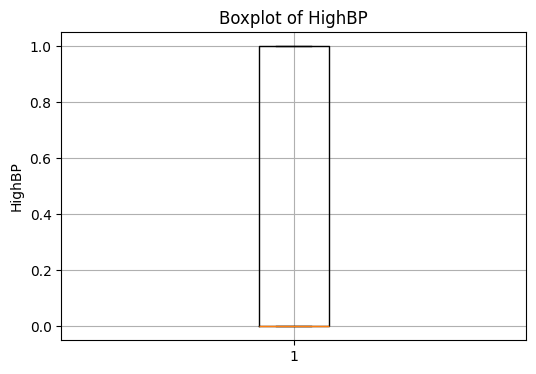

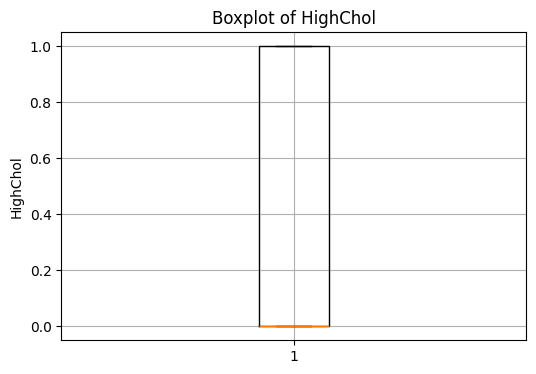

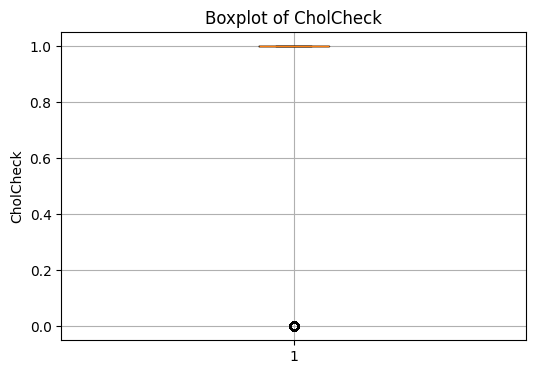

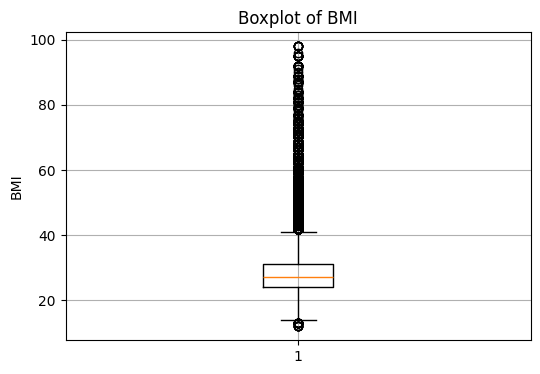

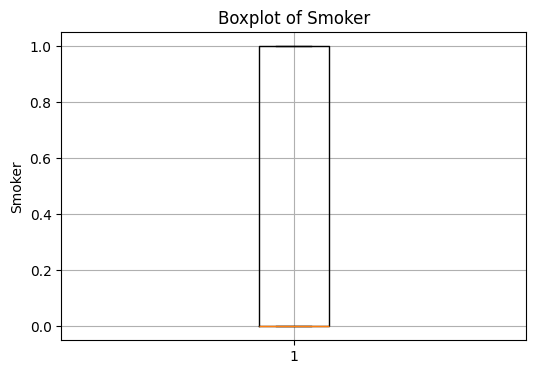

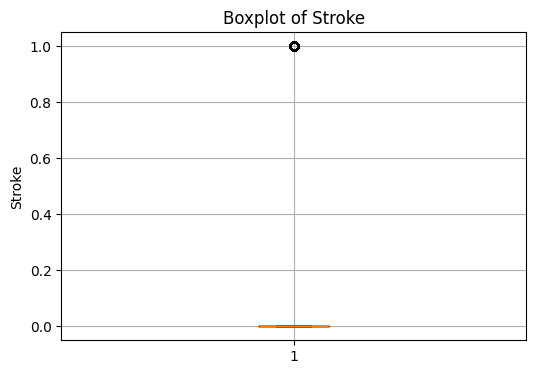

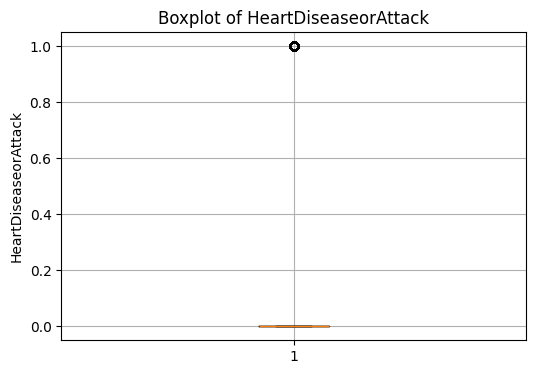

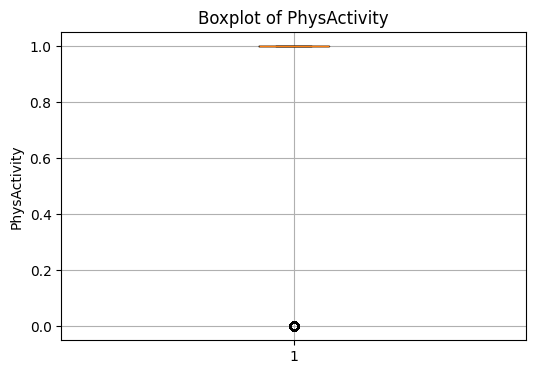

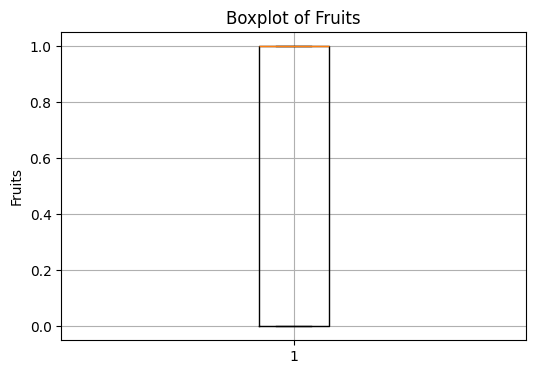

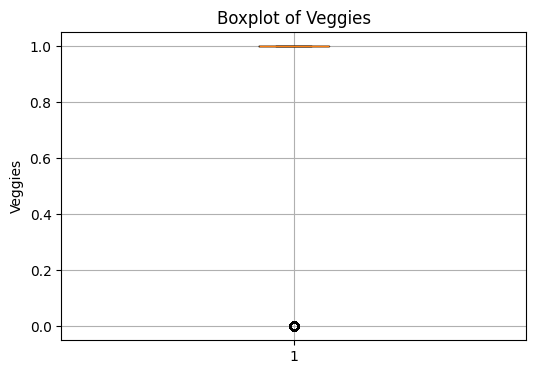

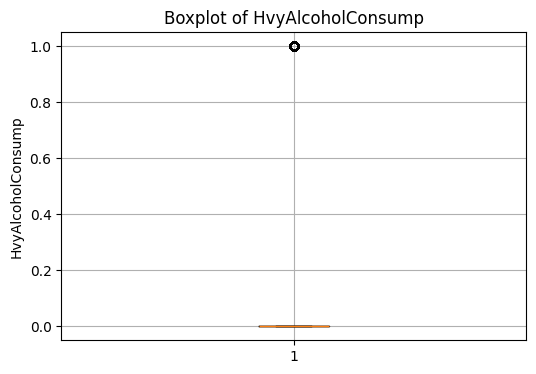

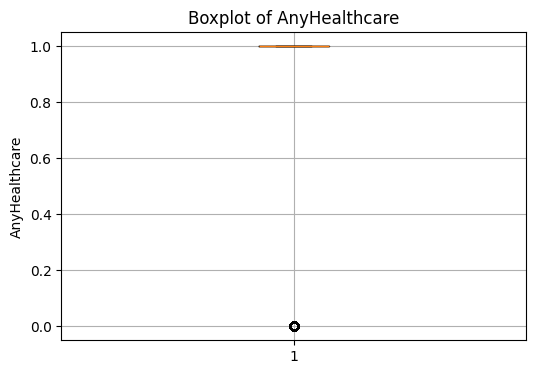

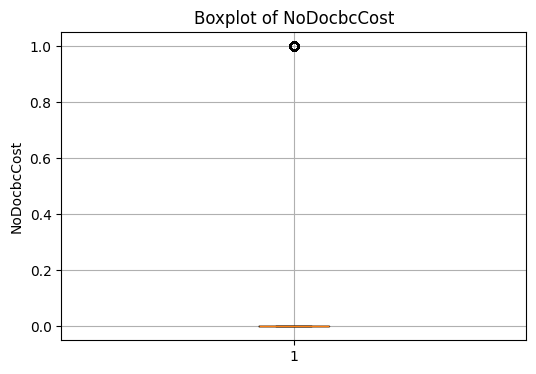

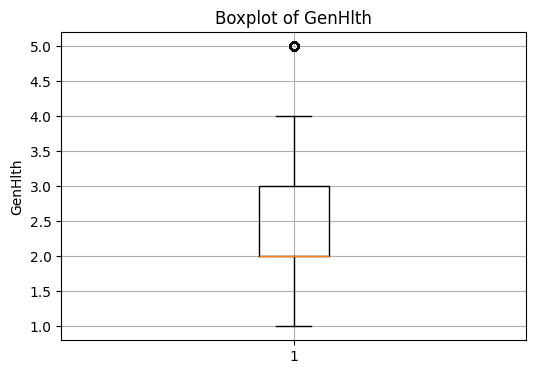

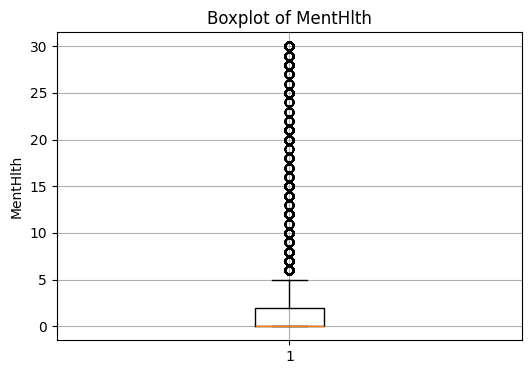

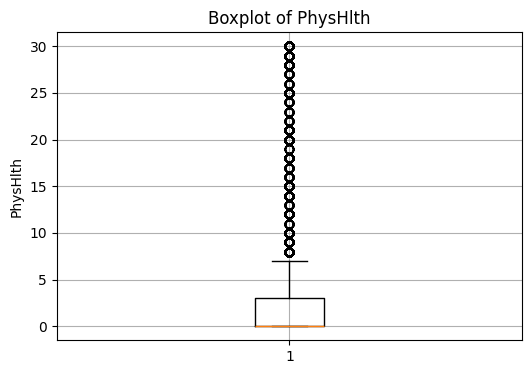

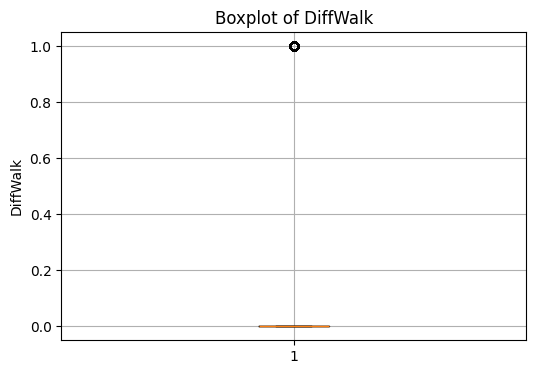

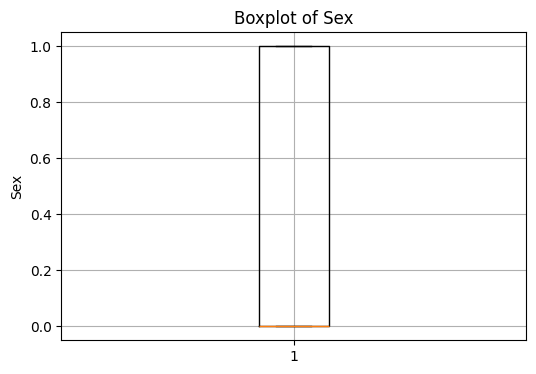

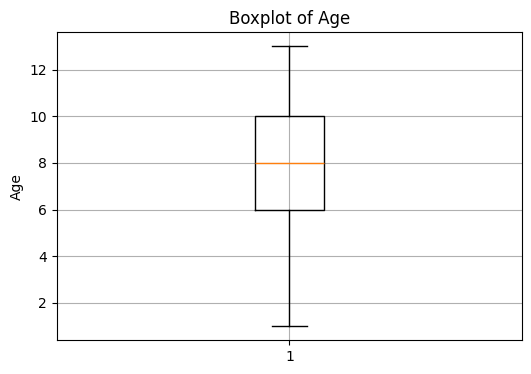

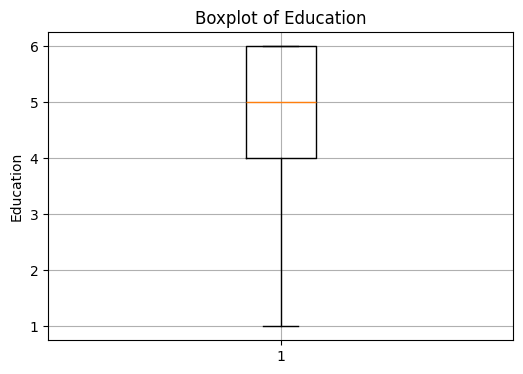

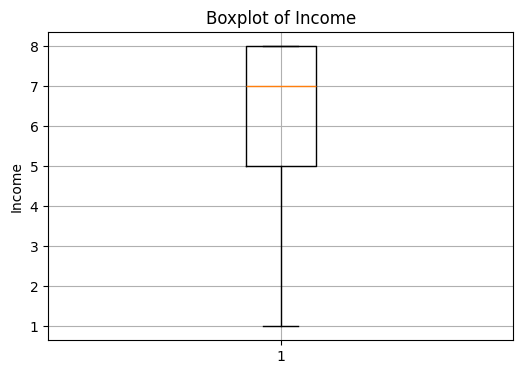

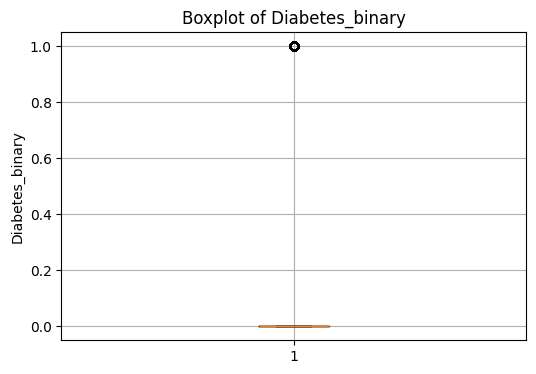

In [9]:
# Boxplots (not separated by class)
numeric_df = df.select_dtypes(include='number')

for column in numeric_df.columns:
    plt.figure(figsize=(6, 4))
    plt.boxplot(df[column])
    plt.title(f"Boxplot of {column}")
    plt.ylabel(column)
    plt.grid(True)
    plt.show()

/tmp/ipykernel_6708/497915885.py:15: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([data0, data1], labels=['Class 0', 'Class 1'])


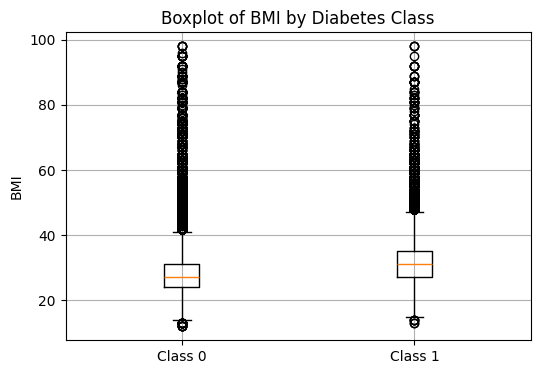

/tmp/ipykernel_6708/497915885.py:15: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([data0, data1], labels=['Class 0', 'Class 1'])


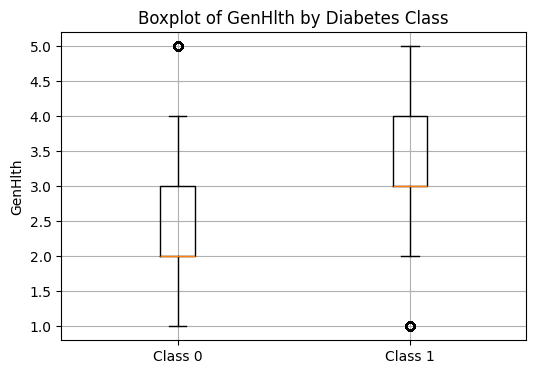

/tmp/ipykernel_6708/497915885.py:15: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([data0, data1], labels=['Class 0', 'Class 1'])


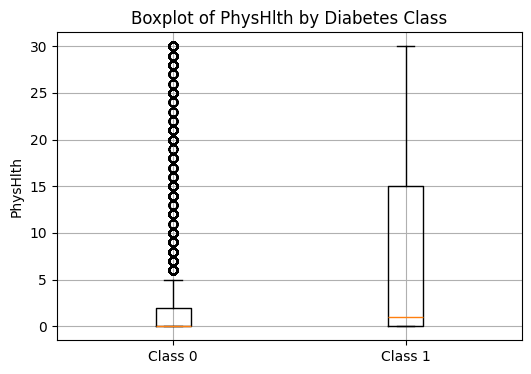

/tmp/ipykernel_6708/497915885.py:15: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([data0, data1], labels=['Class 0', 'Class 1'])


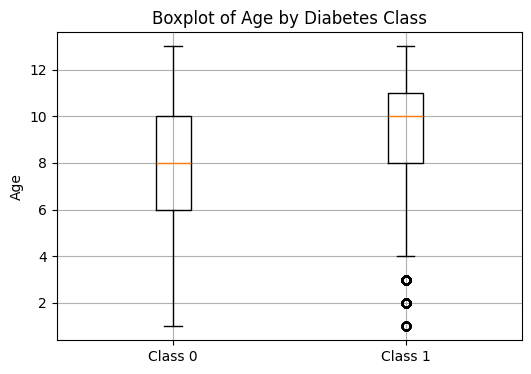

/tmp/ipykernel_6708/497915885.py:15: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([data0, data1], labels=['Class 0', 'Class 1'])


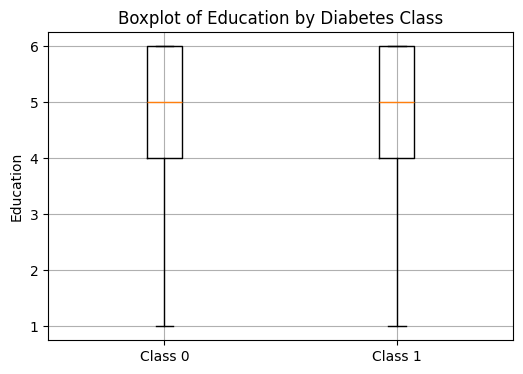

/tmp/ipykernel_6708/497915885.py:15: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([data0, data1], labels=['Class 0', 'Class 1'])


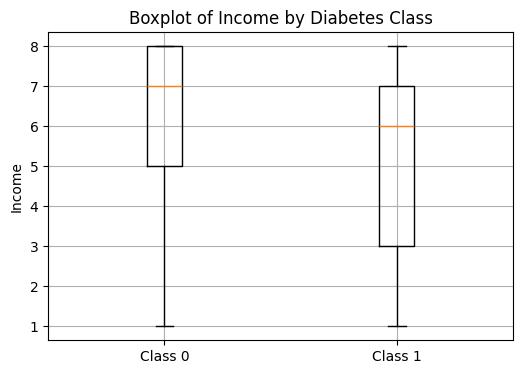

In [10]:
## Boxplots of some variables separated by class

columns = ['BMI', 'GenHlth', 'PhysHlth', 'Age', 'Education', 'Income']
target = 'Diabetes_binary'

for col in columns:
    data0 = df[df[target] == 0][col]
    data1 = df[df[target] == 1][col]
    data2 = df[df[target] == 2][col] if 2 in df[target].unique() else None

    plt.figure(figsize=(6, 4))
    if data2 is not None:
        plt.boxplot([data0, data1, data2], labels=['Class 0', 'Class 1', 'Class 2'])
    else:
        plt.boxplot([data0, data1], labels=['Class 0', 'Class 1'])
    plt.title(f"Boxplot of {col} by Diabetes Class")
    plt.ylabel(col)
    plt.grid(True)
    plt.show()

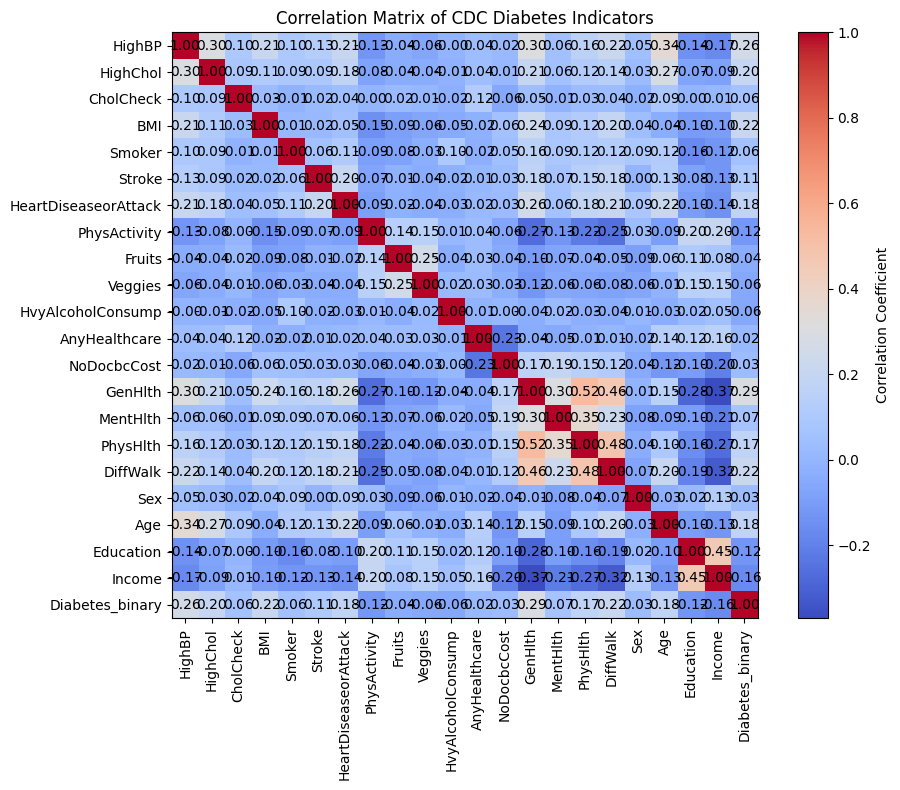

In [11]:
## Correlation Matrix

# Calculate the correlation matrix
c_df = df.corr(numeric_only=True)

plt.figure(figsize=(10, 8))
plt.imshow(c_df, cmap='coolwarm', interpolation='none')
plt.colorbar(label='Correlation Coefficient')

# Add the correlation values on the heatmap
for i in range(len(c_df.columns)):
    for j in range(len(c_df.columns)):
        plt.text(j, i, f'{c_df.iloc[i, j]:.2f}', ha='center', va='center', color='black')

plt.xticks(ticks=np.arange(len(c_df.columns)), labels=c_df.columns, rotation=90)
plt.yticks(ticks=np.arange(len(c_df.columns)), labels=c_df.columns)
plt.title("Correlation Matrix of CDC Diabetes Indicators")
plt.tight_layout()
plt.show()

BMI


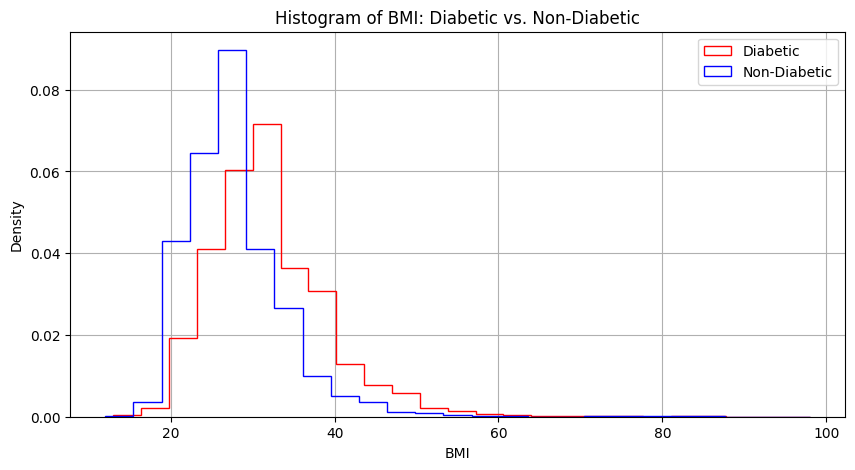

GenHlth


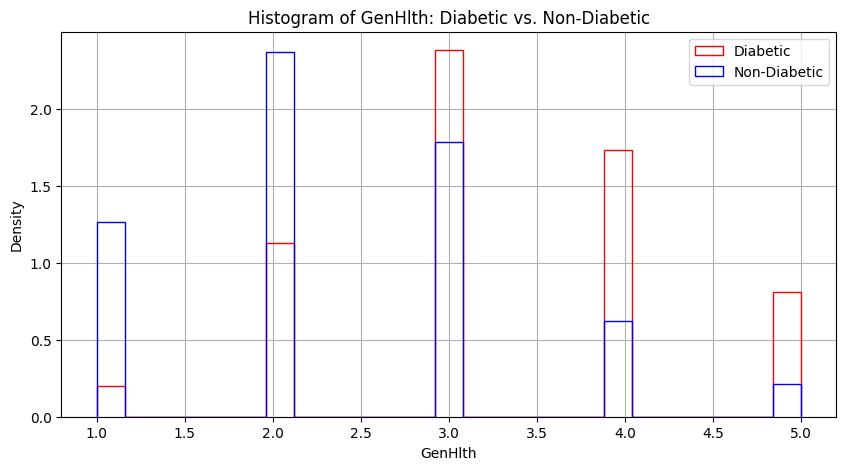

PhysHlth


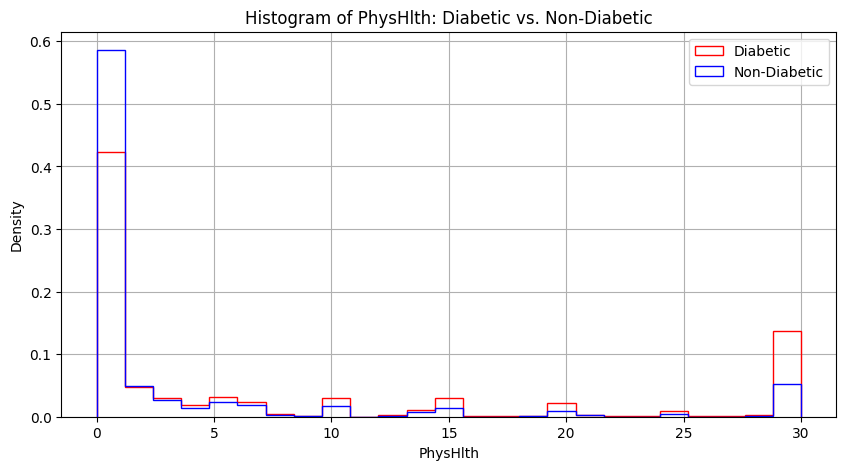

Age


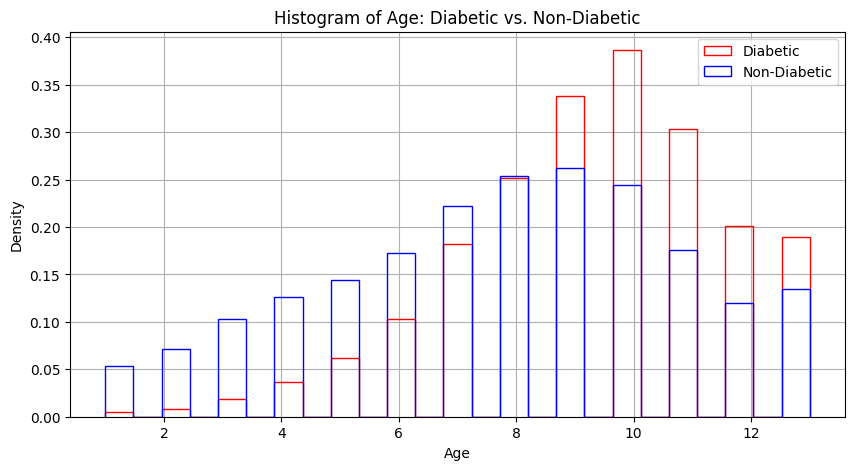

Education


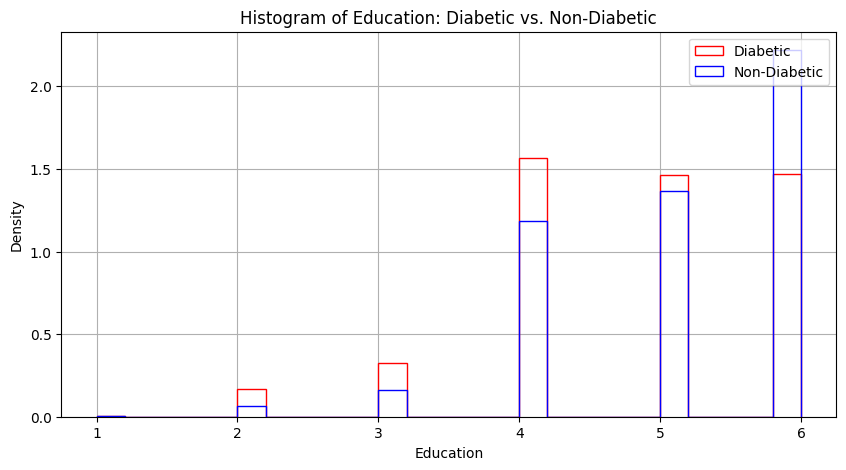

Income


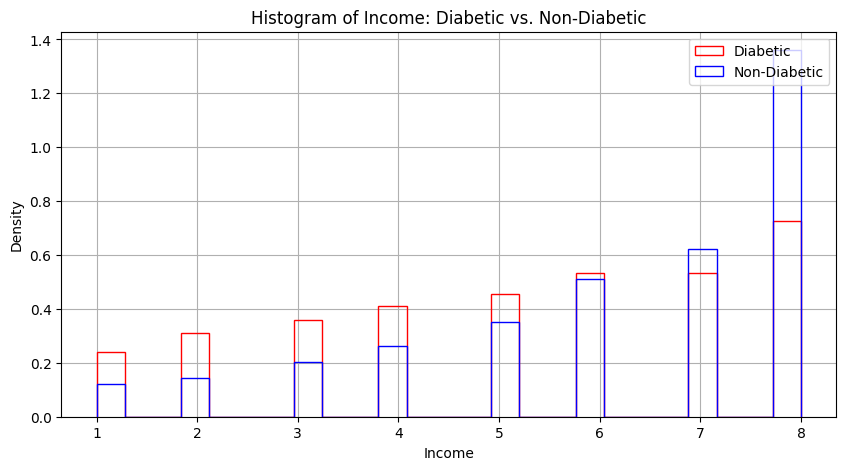

In [12]:
# Just Integer Features

VarNames = ['BMI', 'GenHlth', 'PhysHlth', 'Age', 'Education', 'Income']

df_sig = df[df['Diabetes_binary'] != 0]
df_bkg = df[df['Diabetes_binary'] == 0]

for var in VarNames:
    print(var)
    plt.figure(figsize=(10, 5))
    plt.hist(np.array(df_sig[var]), bins=25, histtype="step", color="red", label="Diabetic", density=True, stacked=True)
    plt.hist(np.array(df_bkg[var]), bins=25, histtype="step", color="blue", label="Non-Diabetic", density=True, stacked=True)
    plt.legend(loc='upper right')
    plt.title(f"Histogram of {var}: Diabetic vs. Non-Diabetic")
    plt.xlabel(var)
    plt.ylabel("Density")
    plt.grid(True)
    plt.show()

HighBP


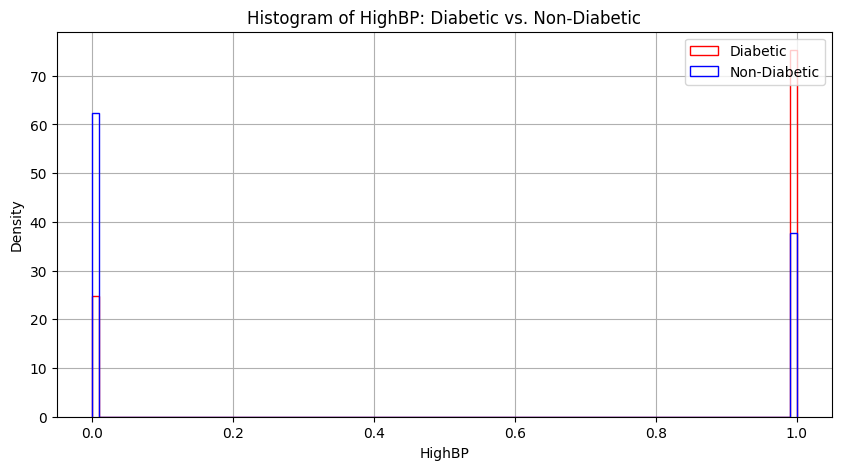

HighChol


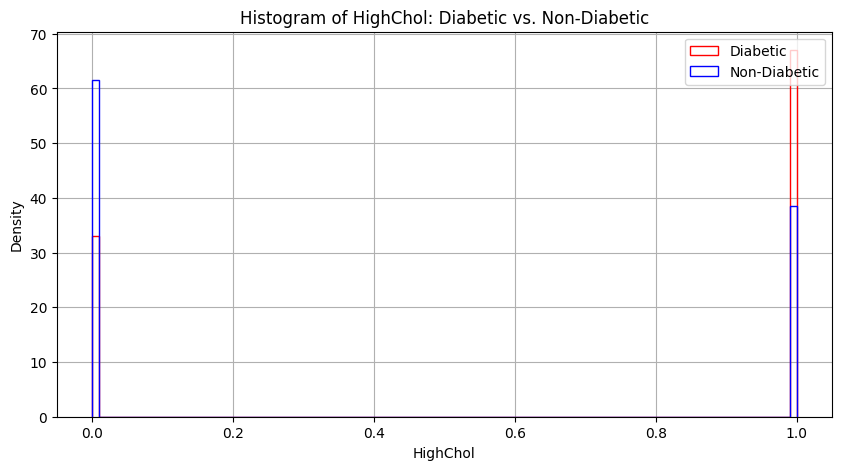

CholCheck


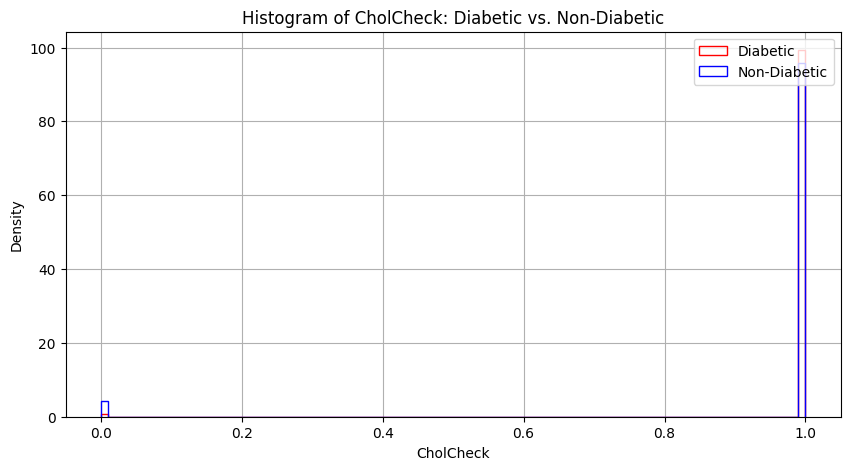

BMI


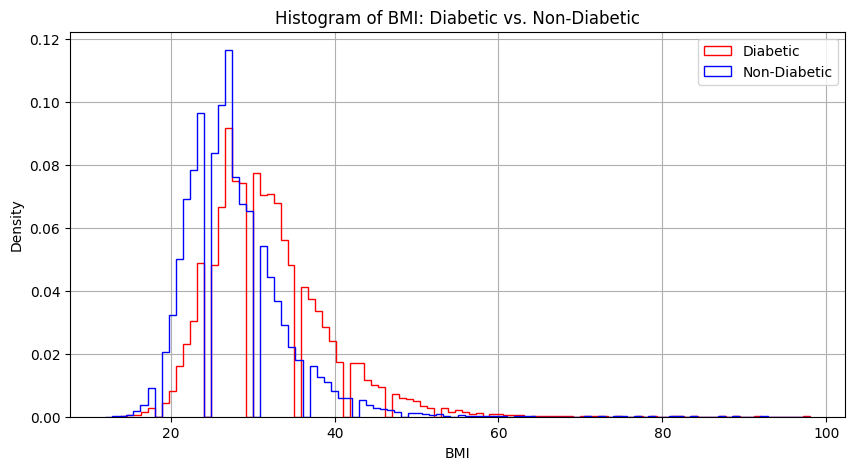

Smoker


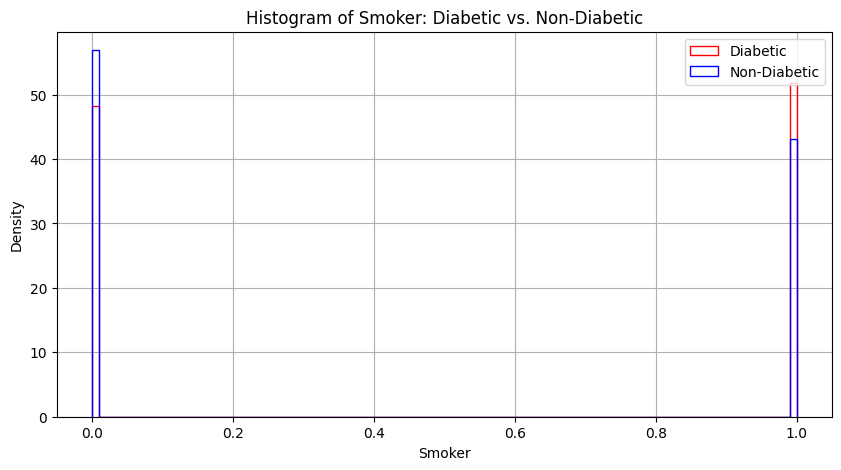

Stroke


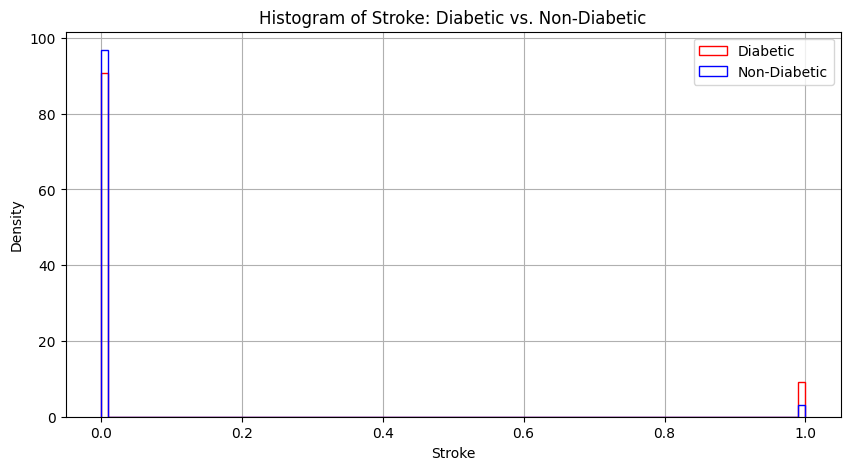

HeartDiseaseorAttack


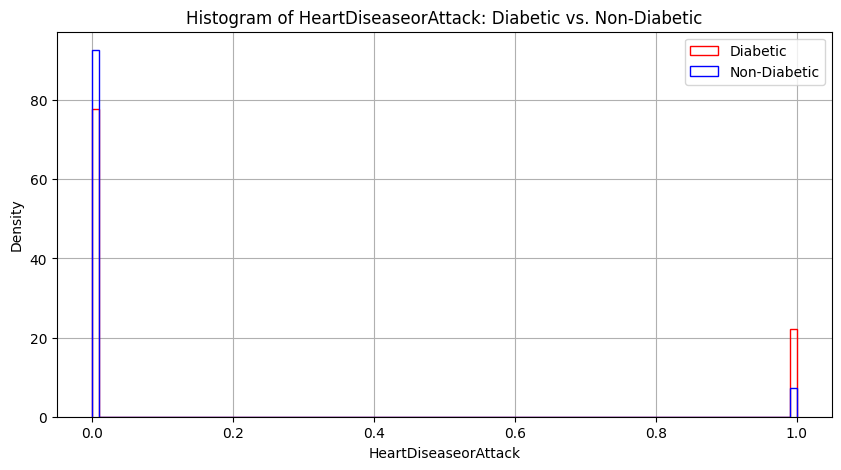

PhysActivity


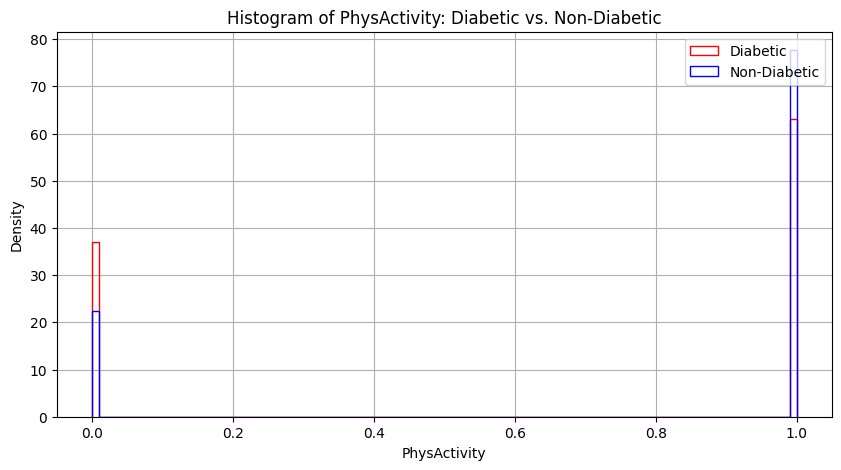

Fruits


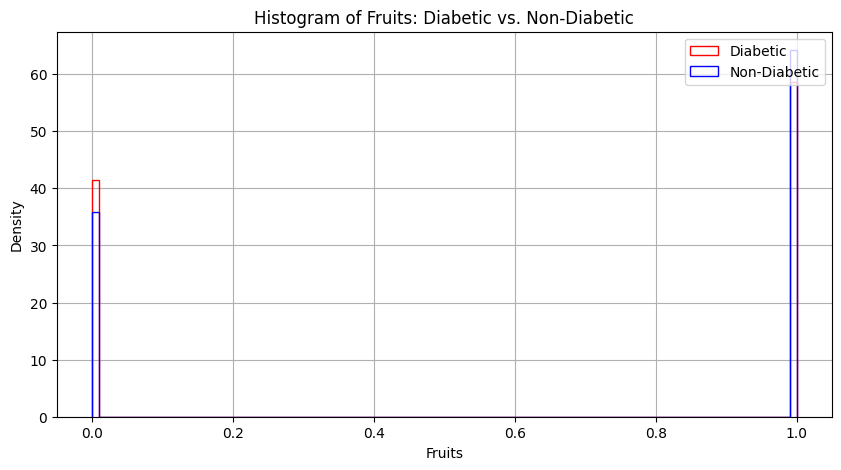

Veggies


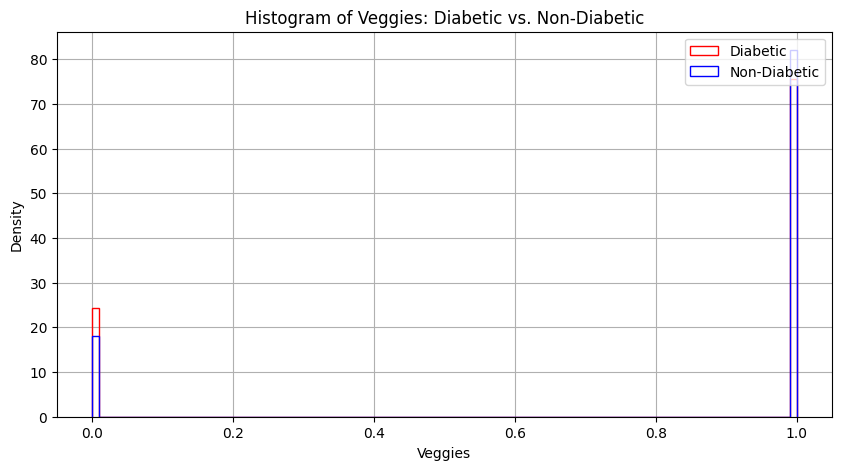

HvyAlcoholConsump


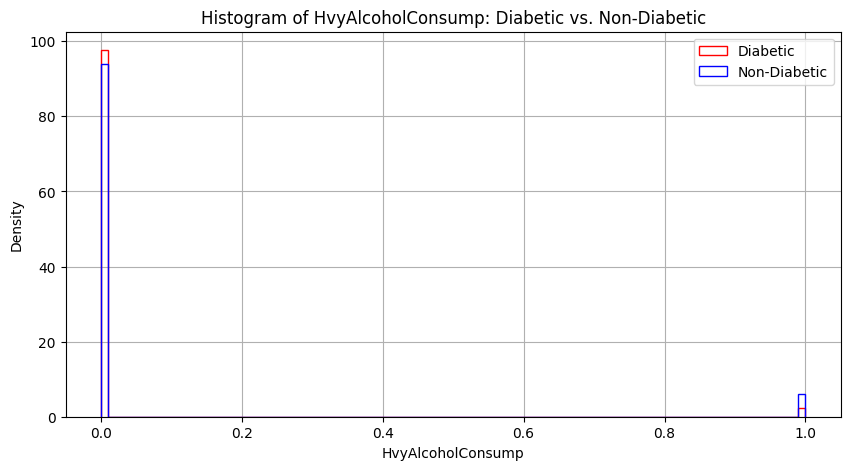

AnyHealthcare


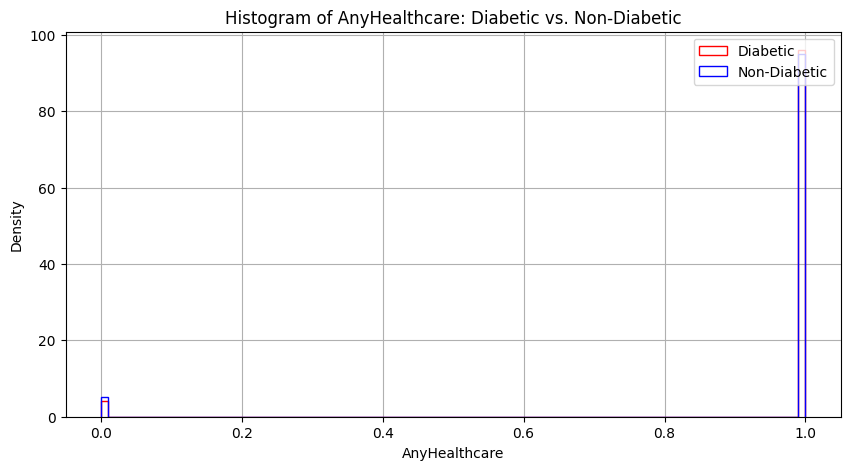

NoDocbcCost


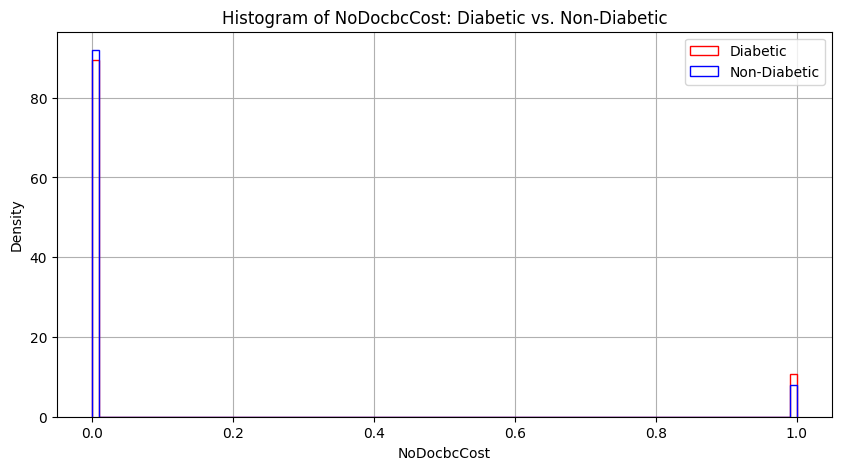

GenHlth


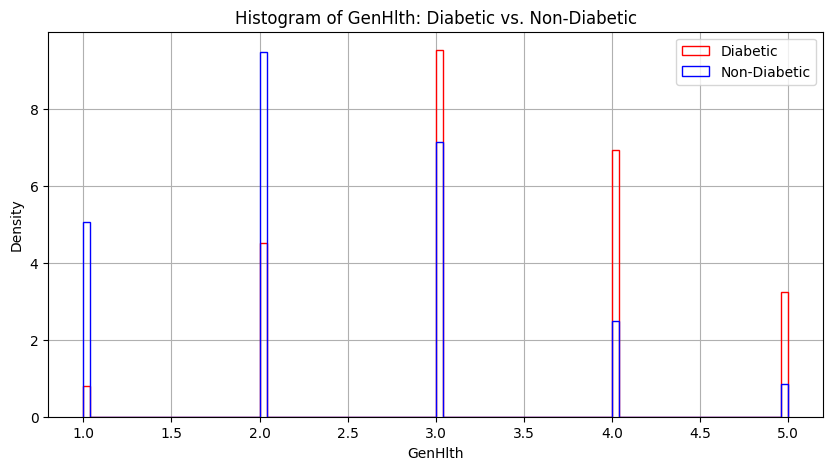

MentHlth


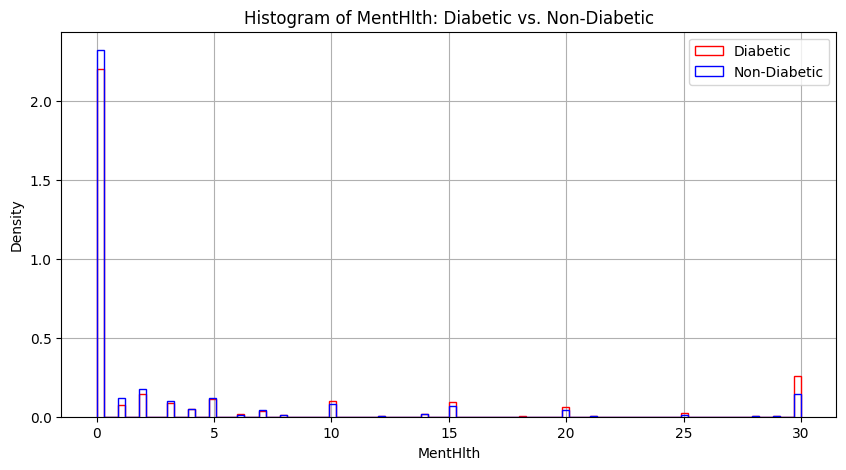

PhysHlth


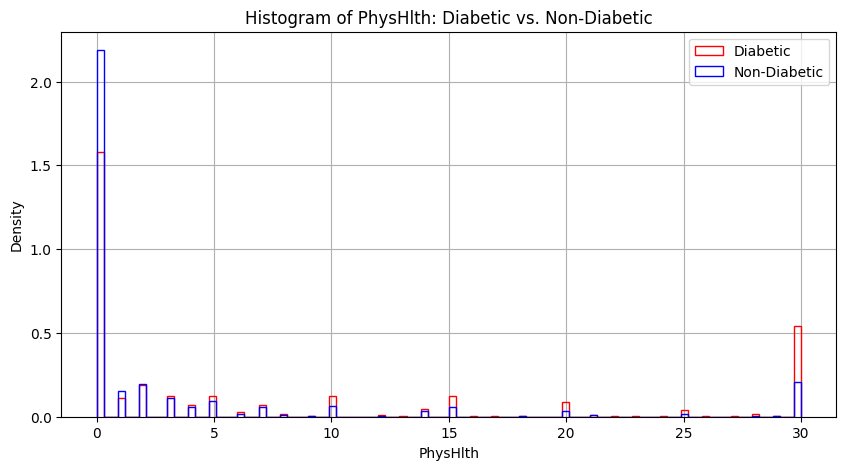

DiffWalk


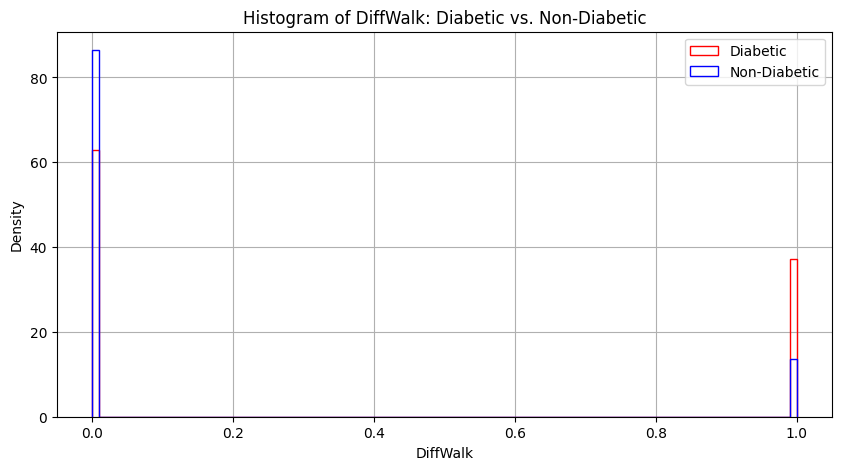

Sex


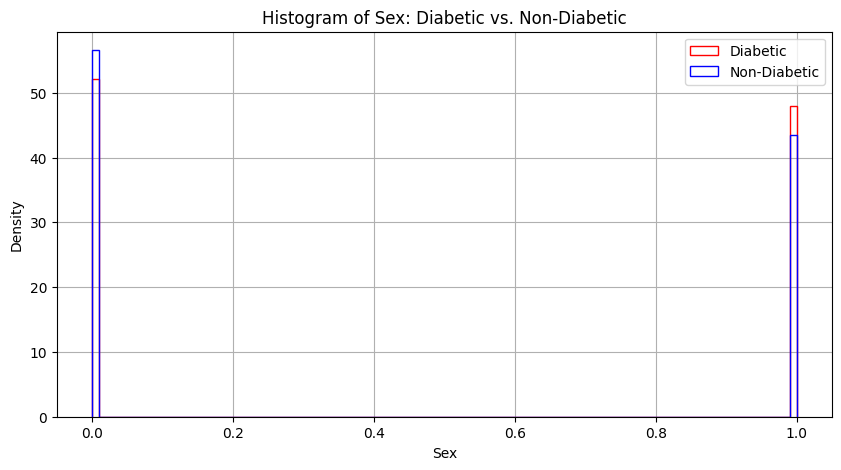

Age


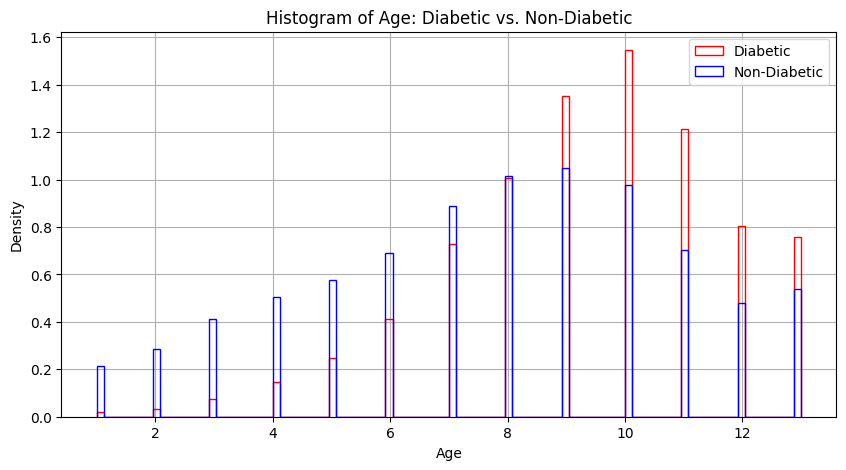

Education


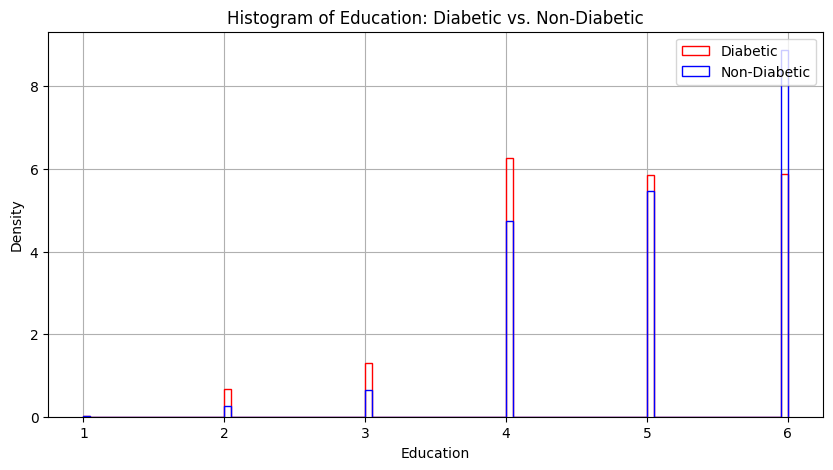

Income


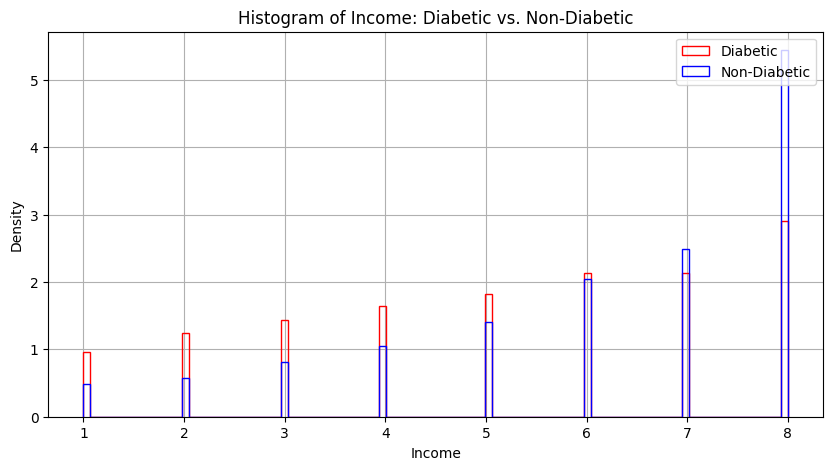

Diabetes_binary


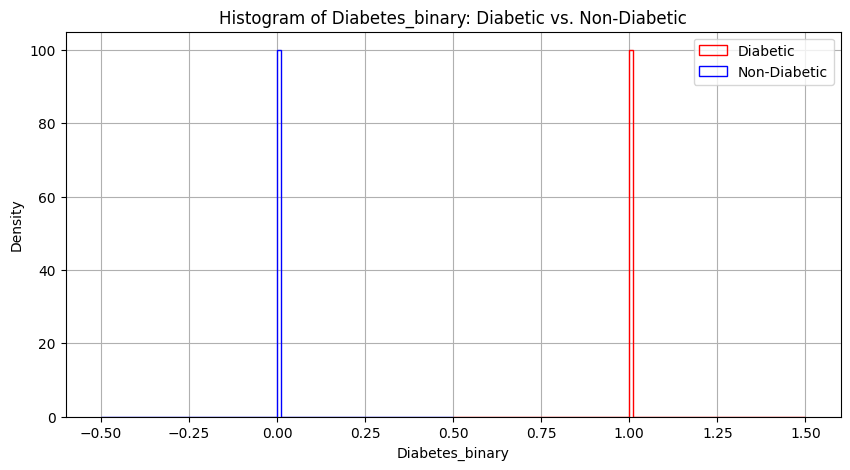

In [13]:
# ALL VARIABLES
VarNames = df.select_dtypes(include='number').columns.tolist()

df_sig = df[df['Diabetes_binary'] != 0]  # signal = diabetic
df_bkg = df[df['Diabetes_binary'] == 0]  # background = non-diabetic

for var in VarNames:
    print(var)
    plt.figure(figsize=(10, 5))
    plt.hist(np.array(df_sig[var]), bins=100, histtype="step", color="red", label="Diabetic", density=True, stacked=True)
    plt.hist(np.array(df_bkg[var]), bins=100, histtype="step", color="blue", label="Non-Diabetic", density=True, stacked=True)
    plt.legend(loc='upper right')
    plt.title(f"Histogram of {var}: Diabetic vs. Non-Diabetic")
    plt.xlabel(var)
    plt.ylabel("Density")
    plt.grid(True)
    plt.show()

In [14]:
VarNames = df.select_dtypes(include='number').columns.tolist()

df_sig = df[df['Diabetes_binary'] != 0]  # signal = diabetic
df_bkg = df[df['Diabetes_binary'] == 0]  # background = non-diabetic

summary_table = {}

for var in VarNames:
    summary_table[var] = {
        'Diabetic Mean': df_sig[var].mean(),
        'Diabetic Std': df_sig[var].std(),
        'Diabetic 25th Percentile': df_sig[var].quantile(0.25),
        'Diabetic 50th Percentile (Median)': df_sig[var].quantile(0.5),
        'Diabetic 75th Percentile': df_sig[var].quantile(0.75),

        'Non-Diabetic Mean': df_bkg[var].mean(),
        'Non-Diabetic Std': df_bkg[var].std(),
        'Non-Diabetic 25th Percentile': df_bkg[var].quantile(0.25),
        'Non-Diabetic 50th Percentile (Median)': df_bkg[var].quantile(0.5),
        'Non-Diabetic 75th Percentile': df_bkg[var].quantile(0.75)
    }

summary_df = pd.DataFrame(summary_table).T

print(summary_df)

                      Diabetic Mean  Diabetic Std  Diabetic 25th Percentile  \
HighBP                     0.752674      0.431464                       1.0   
HighChol                   0.670118      0.470177                       0.0   
CholCheck                  0.993182      0.082292                       1.0   
BMI                       31.944011      7.363401                      27.0   
Smoker                     0.518220      0.499675                       0.0   
Stroke                     0.092457      0.289675                       0.0   
HeartDiseaseorAttack       0.222882      0.416186                       0.0   
PhysActivity               0.630538      0.482666                       0.0   
Fruits                     0.585441      0.492653                       0.0   
Veggies                    0.756408      0.429255                       1.0   
HvyAlcoholConsump          0.023539      0.151609                       0.0   
AnyHealthcare              0.959769      0.196503   

## Data Cleaning and Preperation for Machine Learning

* Perform any data cleaning. Be clear what are you doing, for what feature. 
* Determinine if rescaling is important for your Machine Learning model.
    * If so select strategy for each feature.
    * Apply rescaling.
* Visualize the features before and after cleaning and rescaling.
* One-hot encode your categorical features.

/tmp/ipykernel_6708/2345382043.py:9: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([df[col] for col in numeric_cols], labels=numeric_cols, vert=True)


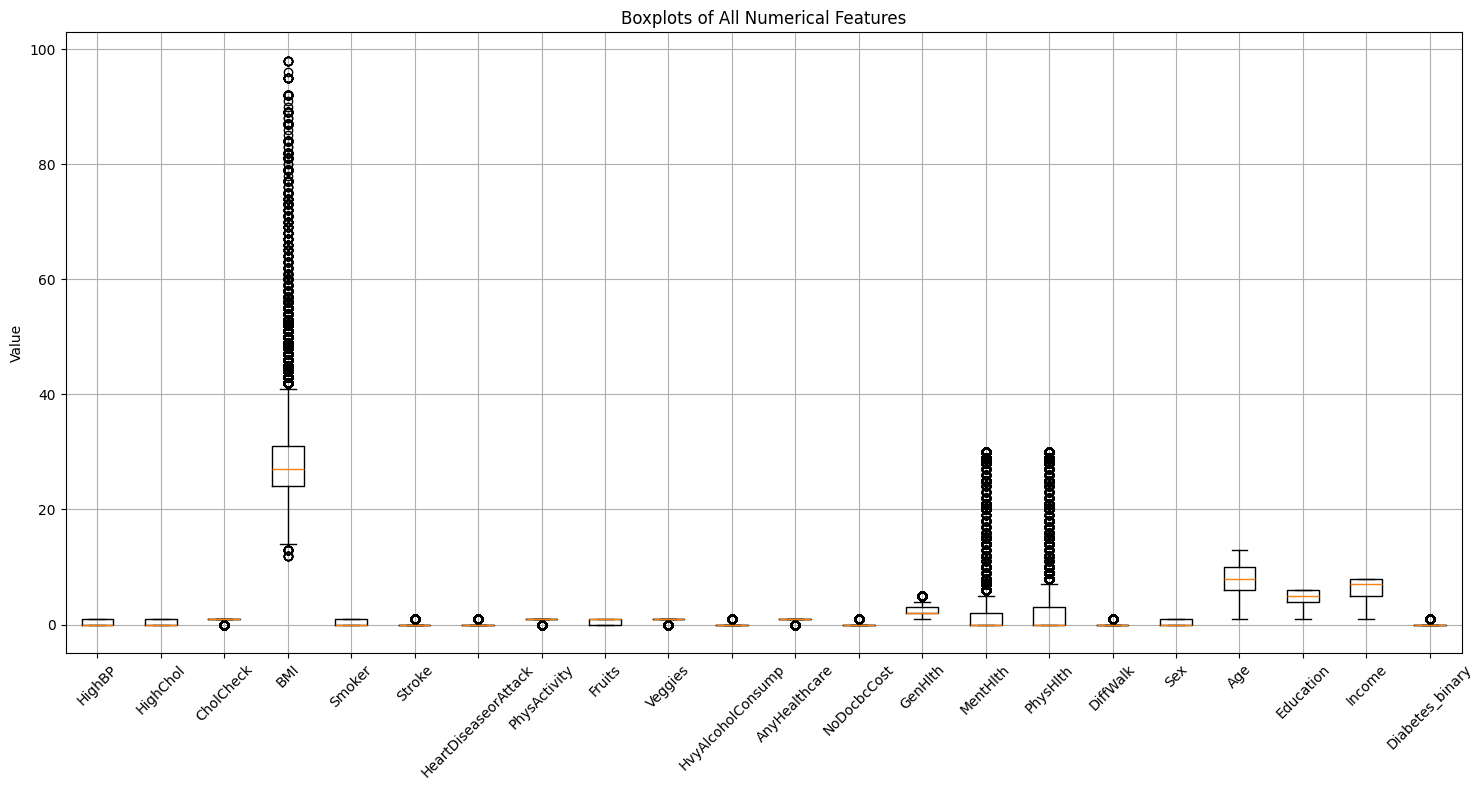

In [15]:
## Handling the outliers for numerical columns
## BEFORE

# Select all numerical columns
numeric_cols = df.select_dtypes(include='number').columns

# Create a boxplot for each column
plt.figure(figsize=(15, 8))
plt.boxplot([df[col] for col in numeric_cols], labels=numeric_cols, vert=True)

plt.title('Boxplots of All Numerical Features')
plt.ylabel('Value')
plt.xticks(rotation=45)
plt.grid(True)
plt.tight_layout()
plt.show()

In [17]:
!pip install scipy

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.1/62.1 kB 685.2 kB/s eta 0:00:000:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 35.2/35.2 MB 7.0 MB/s eta 0:00:0000:0100:01m


/tmp/ipykernel_6708/2595345020.py:15: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([df_no_outliers[col] for col in numeric_cols], labels=numeric_cols, vert=True)


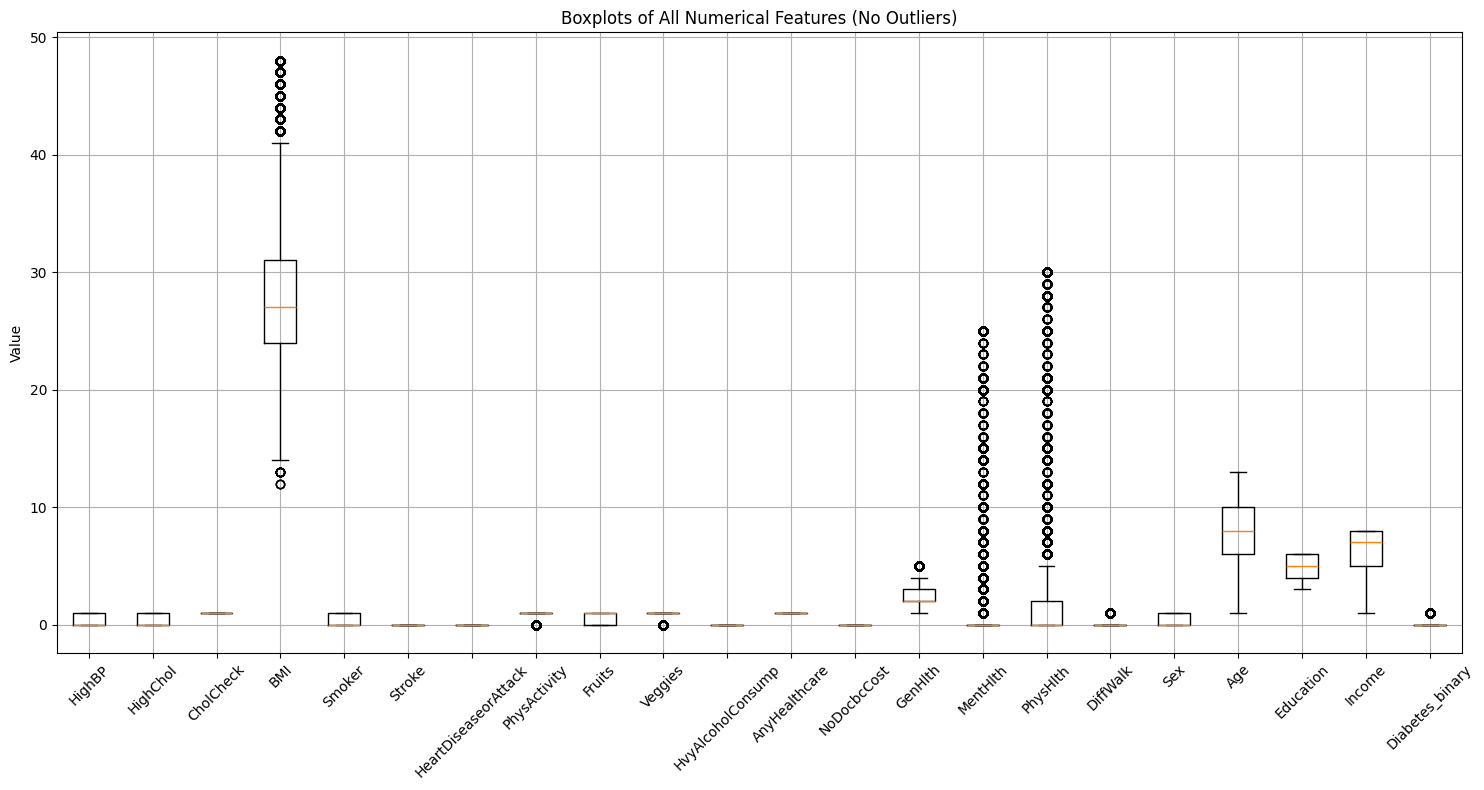

In [18]:
## After handling outliers

import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

numeric_cols = df.select_dtypes(include='number').columns  # Only numeric columns
z_scores = stats.zscore(df[numeric_cols])  # Calculate Z-scores for all numeric columns


df_no_outliers = df[(np.abs(z_scores) < 3).all(axis=1)]

# Create a boxplot for each numerical column after handling outliers
plt.figure(figsize=(15, 8))
plt.boxplot([df_no_outliers[col] for col in numeric_cols], labels=numeric_cols, vert=True)
plt.title('Boxplots of All Numerical Features (No Outliers)')
plt.ylabel('Value')
plt.xticks(rotation=45)
plt.grid(True)
plt.tight_layout()
plt.show()

In [19]:
# BEFORE SCALING
print("Before Scaling (after outlier removal):")
print(df_no_outliers.select_dtypes(include='number').describe())

Before Scaling (after outlier removal):
              HighBP       HighChol  CholCheck            BMI         Smoker  \
count  170236.000000  170236.000000   170236.0  170236.000000  170236.000000   
mean        0.389477       0.395615        1.0      27.847036       0.393031   
std         0.487633       0.488984        0.0       5.475381       0.488425   
min         0.000000       0.000000        1.0      12.000000       0.000000   
25%         0.000000       0.000000        1.0      24.000000       0.000000   
50%         0.000000       0.000000        1.0      27.000000       0.000000   
75%         1.000000       1.000000        1.0      31.000000       1.000000   
max         1.000000       1.000000        1.0      48.000000       1.000000   

         Stroke  HeartDiseaseorAttack   PhysActivity        Fruits  \
count  170236.0              170236.0  170236.000000  170236.00000   
mean        0.0                   0.0       0.792517       0.65734   
std         0.0              

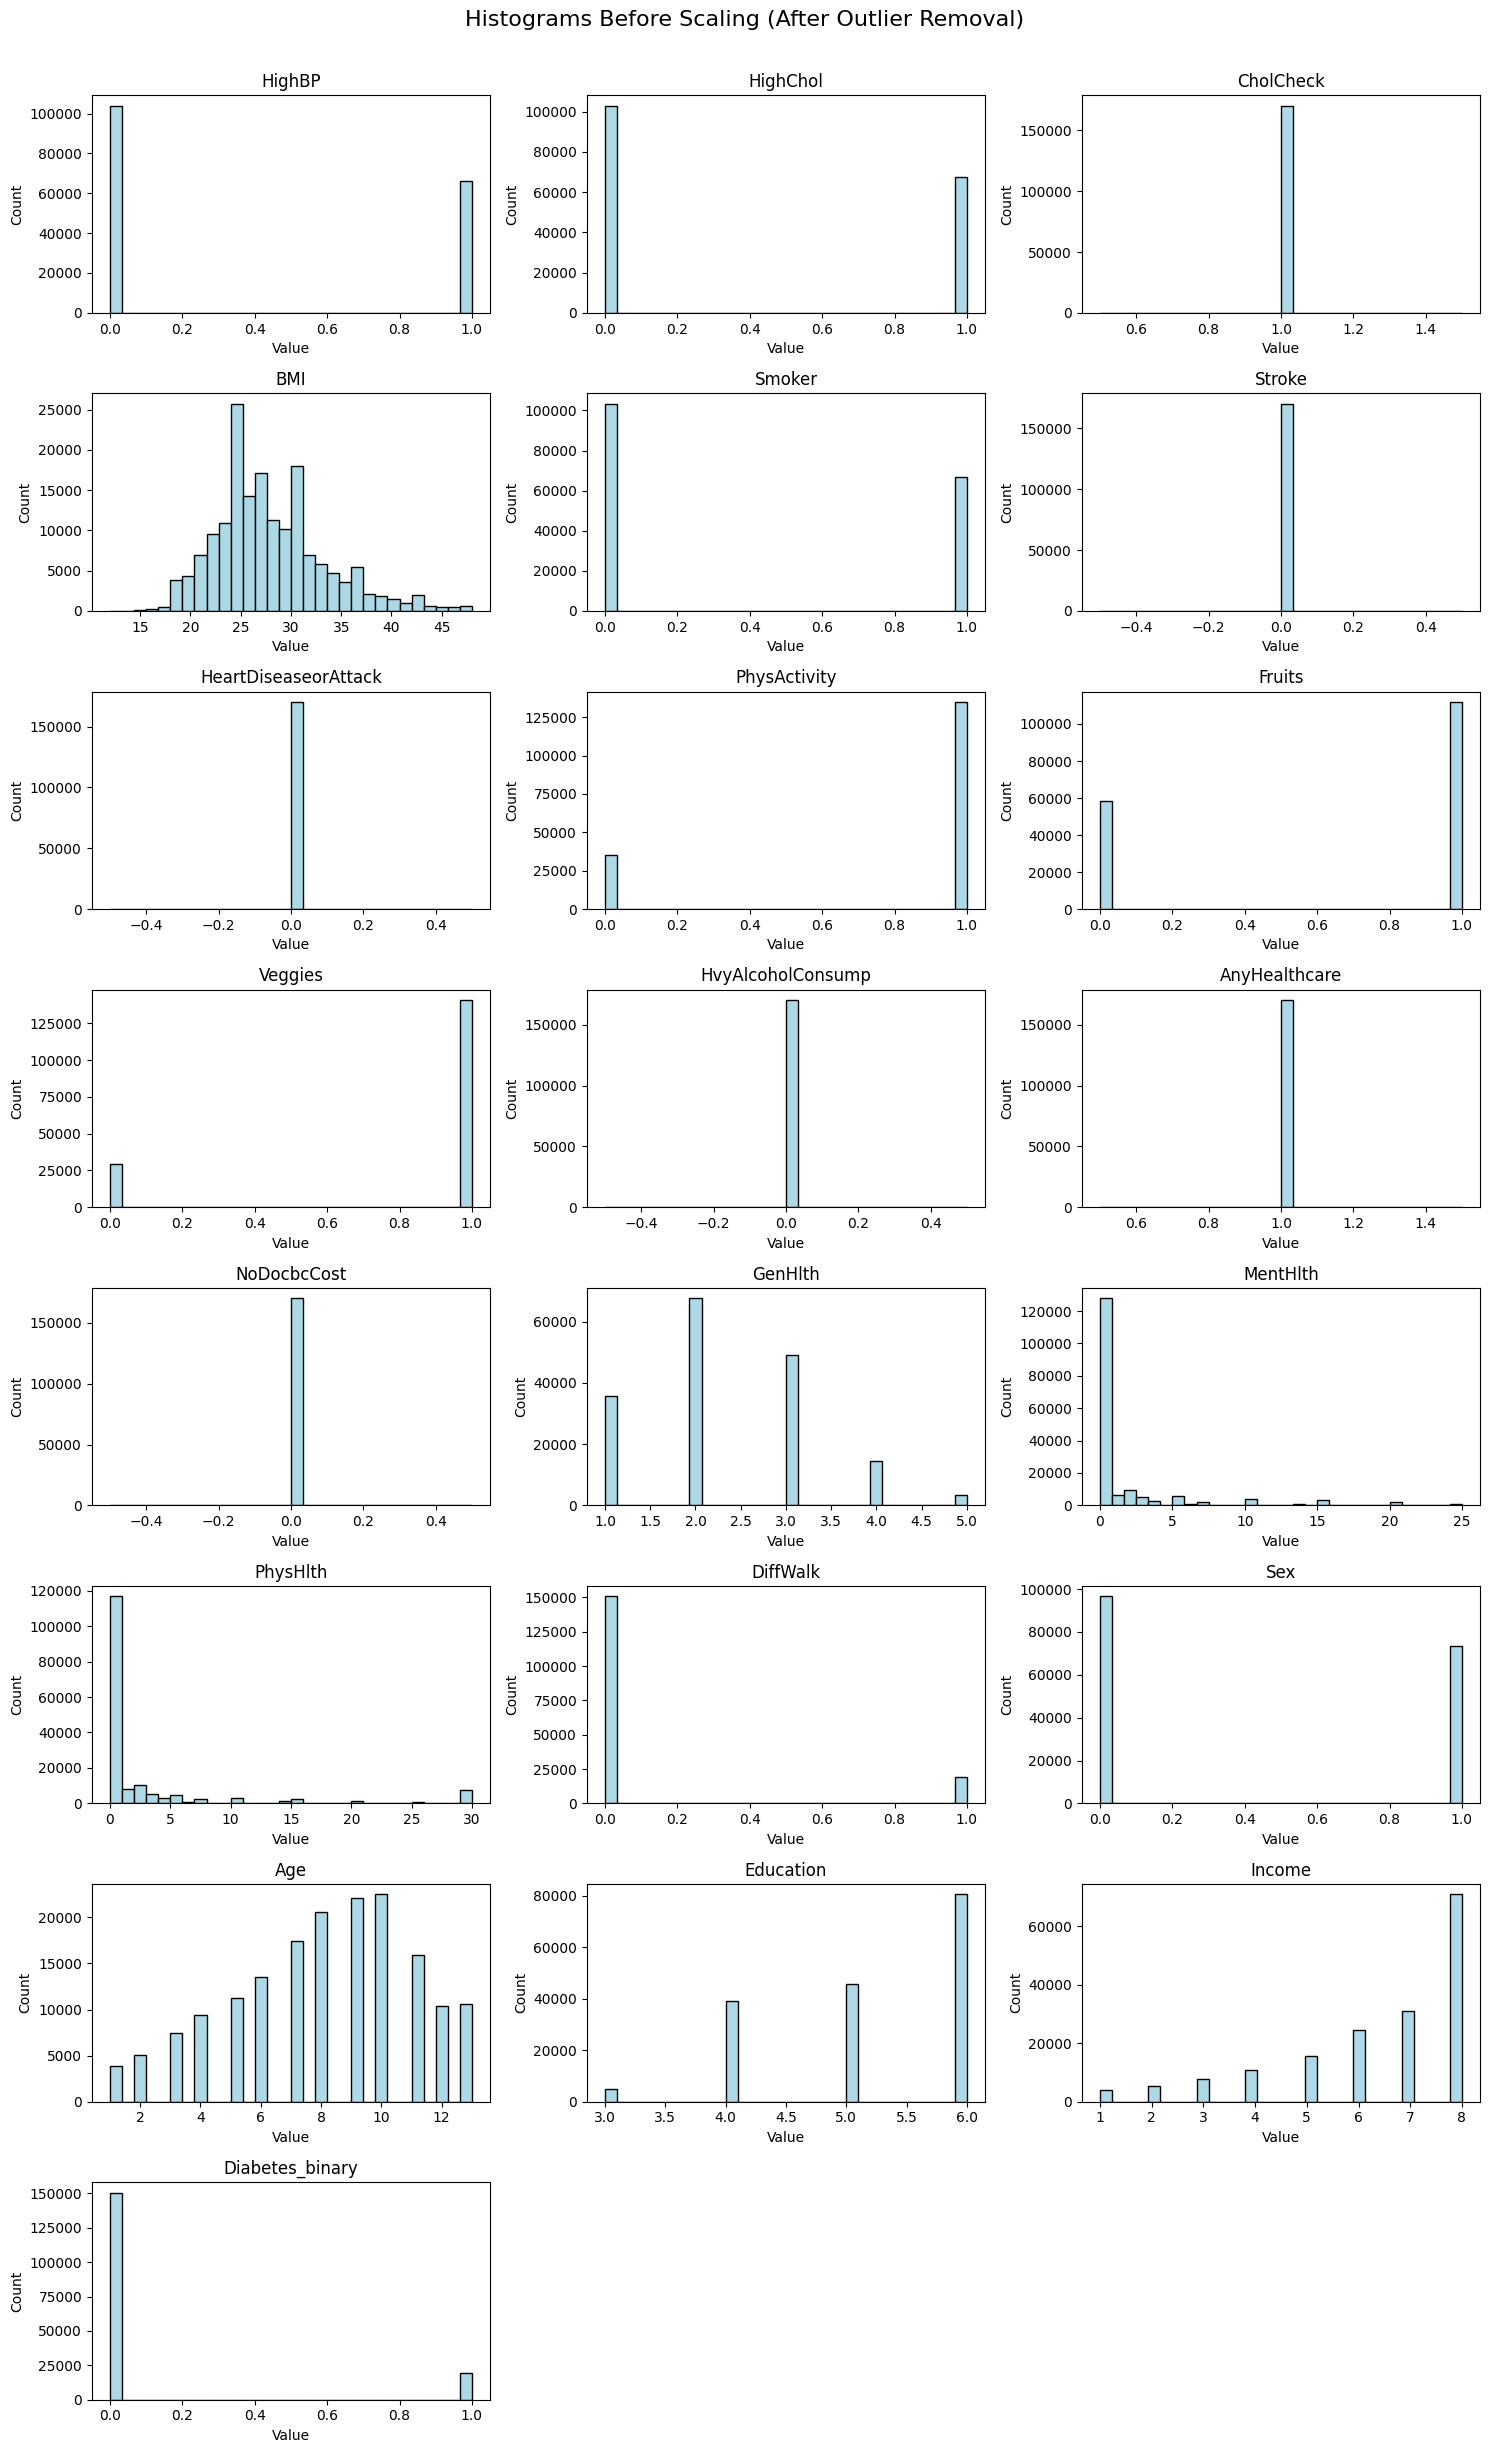

In [20]:
import matplotlib.pyplot as plt

n_cols = 3
n_rows = (len(numeric_cols) + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, n_rows * 3))
axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    axes[i].hist(df_no_outliers[col], bins=30, color='lightblue', edgecolor='black')
    axes[i].set_title(f'{col}')
    axes[i].set_xlabel('Value')
    axes[i].set_ylabel('Count')

for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.suptitle('Histograms Before Scaling (After Outlier Removal)', fontsize=16, y=1.02)
plt.show()

In [26]:
!pip install scikit-learn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.9/8.9 MB 7.4 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 309.1/309.1 kB 7.6 MB/s eta 0:00:00:00:01


In [27]:
## AFTER SCALING
from sklearn.preprocessing import StandardScaler

df_scaled = df_no_outliers.copy()

numeric_cols = df_scaled.select_dtypes(include='number').columns

scaler = StandardScaler()
df_scaled[numeric_cols] = scaler.fit_transform(df_scaled[numeric_cols])

print("\nAfter Standard Scaling:")
print(df_scaled[numeric_cols].describe())


After Standard Scaling:
             HighBP      HighChol  CholCheck           BMI        Smoker  \
count  1.702360e+05  1.702360e+05   170236.0  1.702360e+05  1.702360e+05   
mean   2.203803e-17  2.738058e-17        0.0  1.348994e-16  6.277499e-17   
std    1.000003e+00  1.000003e+00        0.0  1.000003e+00  1.000003e+00   
min   -7.987114e-01 -8.090586e-01        0.0 -2.894243e+00 -8.046926e-01   
25%   -7.987114e-01 -8.090586e-01        0.0 -7.026081e-01 -8.046926e-01   
50%   -7.987114e-01 -8.090586e-01        0.0 -1.546994e-01 -8.046926e-01   
75%    1.252017e+00  1.236004e+00        0.0  5.758455e-01  1.242711e+00   
max    1.252017e+00  1.236004e+00        0.0  3.680661e+00  1.242711e+00   

         Stroke  HeartDiseaseorAttack  PhysActivity        Fruits  \
count  170236.0              170236.0  1.702360e+05  1.702360e+05   
mean        0.0                   0.0  3.940132e-17 -5.676462e-17   
std         0.0                   0.0  1.000003e+00  1.000003e+00   
min         0.

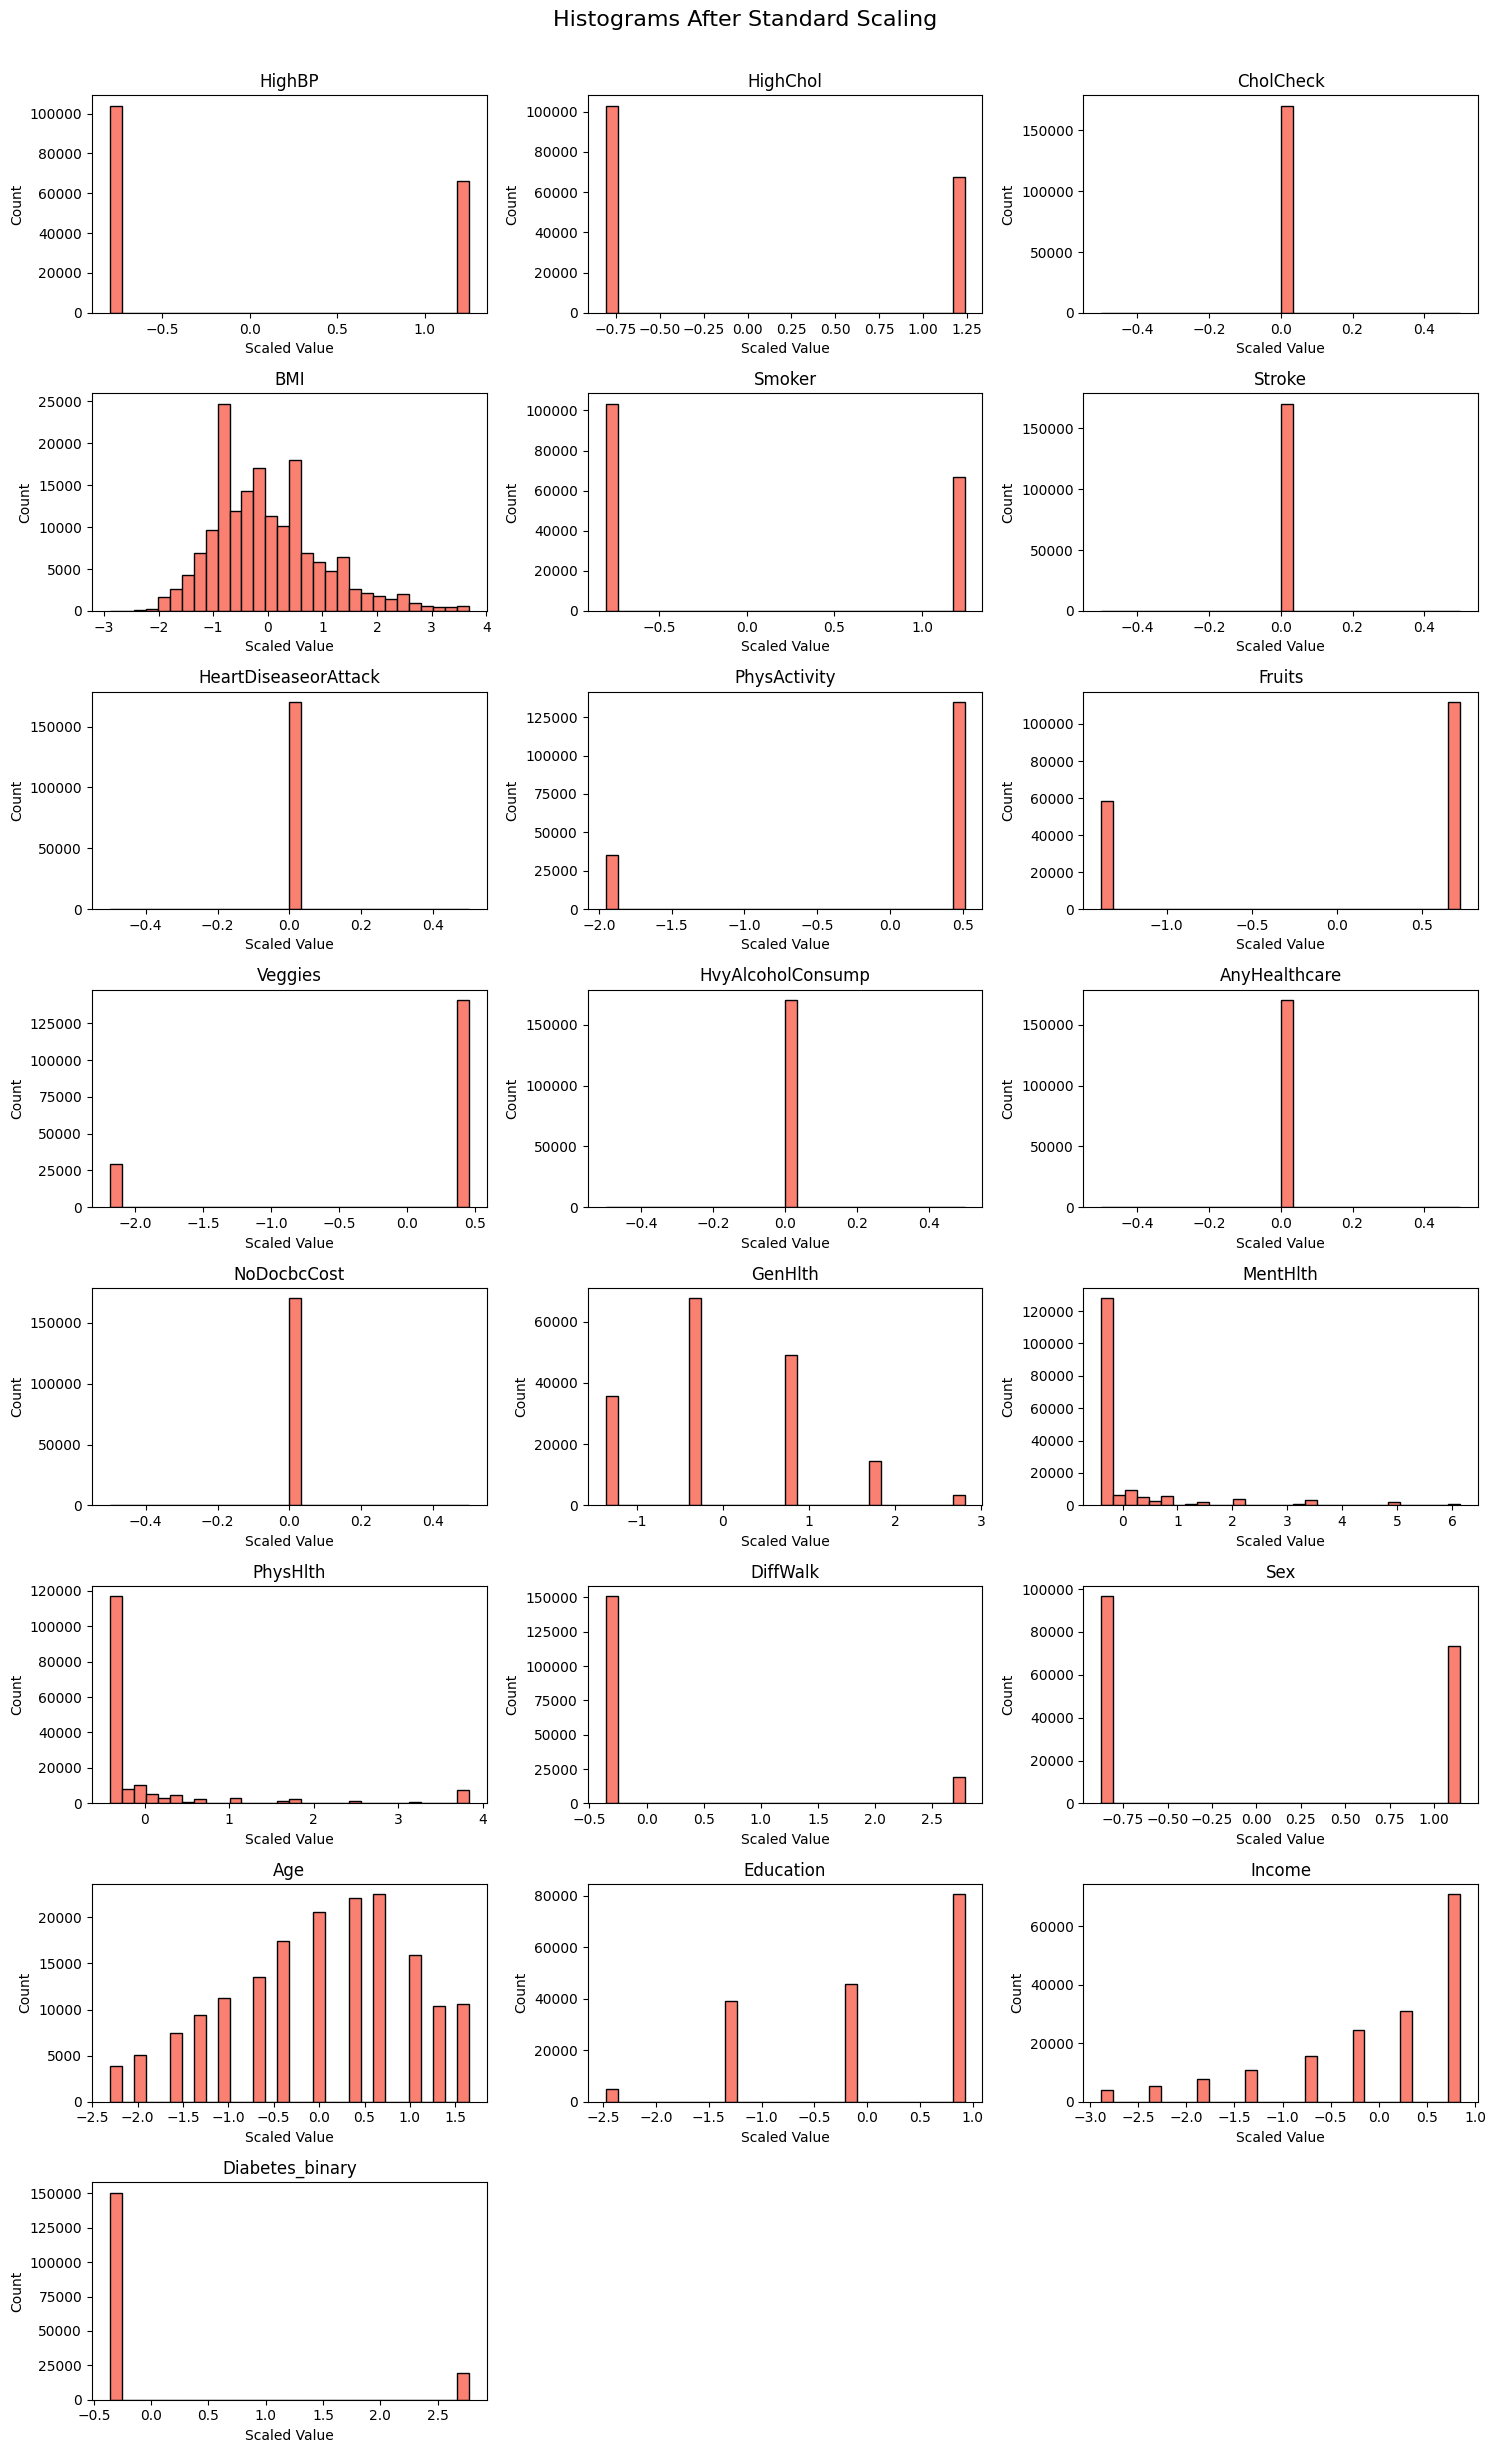

In [28]:
# Layout for histograms
n_cols = 3
n_rows = (len(numeric_cols) + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, n_rows * 3))
axes = axes.flatten()

# Plot histograms of each scaled column
for i, col in enumerate(numeric_cols):
    axes[i].hist(df_scaled[col], bins=30, color='salmon', edgecolor='black')
    axes[i].set_title(f'{col}')
    axes[i].set_xlabel('Scaled Value')
    axes[i].set_ylabel('Count')

# Remove unused subplots
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.suptitle('Histograms After Standard Scaling', fontsize=16, y=1.02)
plt.show()

In [29]:
# Check the data types of the columns
print(df.dtypes)

# Identify continuous columns
continuous_cols = df.select_dtypes(include=['float64', 'int64']).columns
print("\nContinuous columns:")
print(continuous_cols)

# Convert all numeric columns to integers
df[df.select_dtypes(include=['float64', 'int64']).columns] = df.select_dtypes(include=['float64', 'int64']).astype(int)

# Check the updated data types
print(df.dtypes)

HighBP                  int64
HighChol                int64
CholCheck               int64
BMI                     int64
Smoker                  int64
Stroke                  int64
HeartDiseaseorAttack    int64
PhysActivity            int64
Fruits                  int64
Veggies                 int64
HvyAlcoholConsump       int64
AnyHealthcare           int64
NoDocbcCost             int64
GenHlth                 int64
MentHlth                int64
PhysHlth                int64
DiffWalk                int64
Sex                     int64
Age                     int64
Education               int64
Income                  int64
Diabetes_binary         int64
dtype: object

Continuous columns:
Index(['HighBP', 'HighChol', 'CholCheck', 'BMI', 'Smoker', 'Stroke',
       'HeartDiseaseorAttack', 'PhysActivity', 'Fruits', 'Veggies',
       'HvyAlcoholConsump', 'AnyHealthcare', 'NoDocbcCost', 'GenHlth',
       'MentHlth', 'PhysHlth', 'DiffWalk', 'Sex', 'Age', 'Education', 'Income',
       'Diabetes_

In [30]:
df = pd.get_dummies(df, drop_first=True)

## Machine Learning


### Problem Formulation

* Remove unneed columns, for example:
    * duplicated
    * categorical features that were turned into one-hot.
    * features that identify specific rows, like ID number.
    * make sure your target is properly encoded also.
* Split training sample into train, validation, and test sub-samples.

### Train ML Algorithm

* You only need one algorithm to work. You can do more if you like.
* For now, focus on making it work, rather than best result.
* Try to get a non-trivial result.

### Evaluate Performance on Validation Sample

* Compute the usual metric for your ML task.
* Compute the score for the kaggle challenge.

### Apply ML to the challenge test set

* Once trained, apply the ML algorithm the the test dataset and generate the submission file.


In [47]:
df_clean = df_no_outliers.copy()

X = df_clean.drop('Diabetes_binary', axis=1)
y = df_clean['Diabetes_binary'].astype(int)

In [48]:
# Removing ID
if 'Id' in df_scaled.columns:
    df_scaled = df_scaled.drop(columns='Id')

In [49]:
############

In [50]:
from sklearn.model_selection import train_test_split

# Separate features and target variable
X = df_scaled.drop('Diabetes_binary', axis=1)
y = df_scaled['Diabetes_binary']

X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.3, random_state=42)

X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42)

In [51]:
print(X_train.shape[0])

119165


In [52]:
print(X_val.shape[0])

25535


In [53]:
print(X_test.shape[0])

25536


In [62]:
# Baseline Model Using RandomForestClassifier

from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(n_estimators=100, random_state=42)


model.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [64]:
from sklearn.metrics import classification_report, confusion_matrix

# 1. Ensure y_val and y_pred are integer types
y_val_int = y_val.astype(int)
y_pred_int = model.predict(X_val).astype(int)

# 2. Now run the evaluation
print("Classification Report:")
print(classification_report(y_val_int, y_pred_int))

print("Confusion Matrix:")
print(confusion_matrix(y_val_int, y_pred_int))

Classification Report:
              precision    recall  f1-score   support

           0       0.88      1.00      0.94     22585
           2       0.00      0.00      0.00      2950

    accuracy                           0.88     25535
   macro avg       0.44      0.50      0.47     25535
weighted avg       0.78      0.88      0.83     25535

Confusion Matrix:
[[22585     0]
 [ 2950     0]]


/home/minahal/myenv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/minahal/myenv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/minahal/myenv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


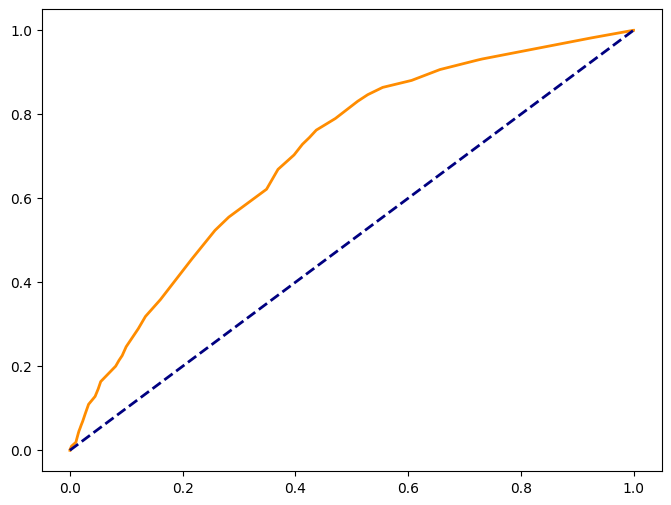

In [68]:
# 1. Map the labels so 2 becomes 1 (Positive Class)
y_test_binary = y_test.astype(int).replace(2, 1)

# 2. Get probabilities for the positive class
y_probs = model.predict_proba(X_test)[:, 1]

# 3. Compute ROC curve using the re-mapped labels
fpr, tpr, thresholds = roc_curve(y_test_binary, y_probs)
roc_auc = auc(fpr, tpr)

# 4. Plotting (Your existing plotting code)
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
# ... (rest of your plot code)
plt.show()

Detected labels in your data: [np.float64(-0.3607873301913733), np.float64(2.771715956515345)]


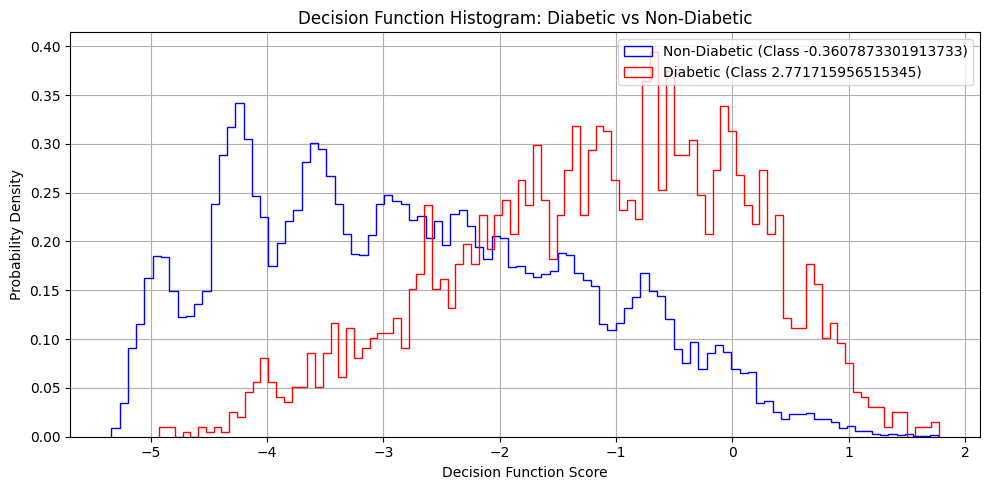

In [72]:
from sklearn.linear_model import LogisticRegression
import matplotlib.pyplot as plt

# 1. Train the classifier
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

# 2. Get the actual unique labels present in your validation set
labels = sorted(y_val.unique())
print(f"Detected labels in your data: {labels}")

# 3. Dynamically assign X_val_0 and X_val_1 based on those labels
# We assume the smaller number is Healthy (0) and the larger is Diabetic (1 or 2)
healthy_label = labels[0]
diabetic_label = labels[1]

X_val_0 = X_val[y_val == healthy_label]
X_val_1 = X_val[y_val == diabetic_label]

# 4. Plotting
plt.figure(figsize=(10, 5))

# Plot Non-Diabetic
plt.hist(model.decision_function(X_val_0), bins=100, histtype="step", 
         color="blue", label=f"Non-Diabetic (Class {healthy_label})", density=True)

# Plot Diabetic
plt.hist(model.decision_function(X_val_1), bins=100, histtype="step", 
         color="red", label=f"Diabetic (Class {diabetic_label})", density=True)

plt.legend(loc='upper right')
plt.xlabel("Decision Function Score")
plt.ylabel("Probability Density")
plt.title("Decision Function Histogram: Diabetic vs Non-Diabetic")
plt.grid(True)
plt.tight_layout()
plt.show()

In [74]:
!pip install imblearn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 235.4/235.4 kB 3.7 MB/s eta 0:00:00a 0:00:01


In [81]:
## Using SMOTE to fix our imbalanced dataset

from imblearn.over_sampling import SMOTE
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix


X = df.drop('Diabetes_binary', axis=1)
y = df['Diabetes_binary']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)


smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)


model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train_smote, y_train_smote)

# (using the original test data)
y_pred = model.predict(X_test)

# Evaluate the model
print(classification_report(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.91      0.84      0.87     65605
           1       0.32      0.47      0.38     10499

    accuracy                           0.79     76104
   macro avg       0.61      0.66      0.63     76104
weighted avg       0.83      0.79      0.80     76104

[[54984 10621]
 [ 5536  4963]]


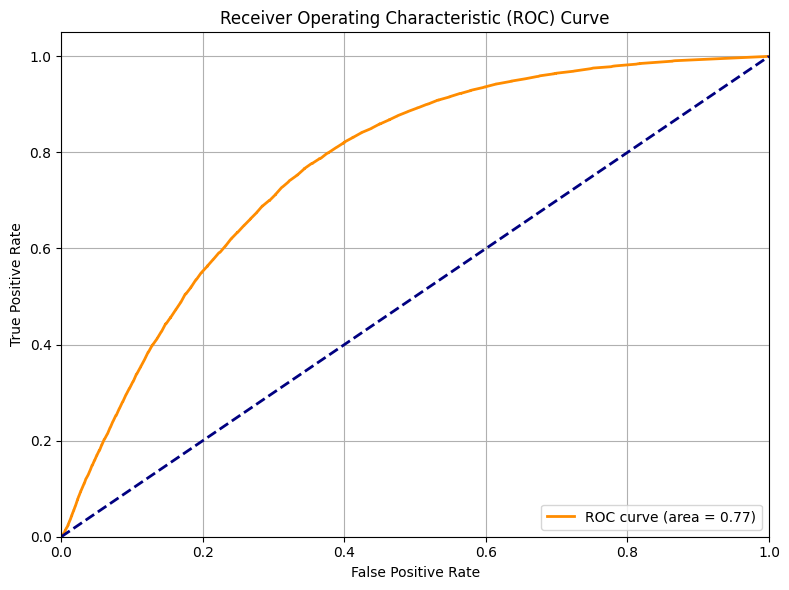

In [82]:
## ROC Curve after
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

y_probs = model.predict_proba(X_test)[:, 1]


fpr, tpr, thresholds = roc_curve(y_test, y_probs)

roc_auc = auc(fpr, tpr)


plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc='lower right')
plt.grid(True)
plt.tight_layout()
plt.show()


I found these labels in your data: [np.float64(-0.3607873301913733), np.float64(2.771715956515345)]


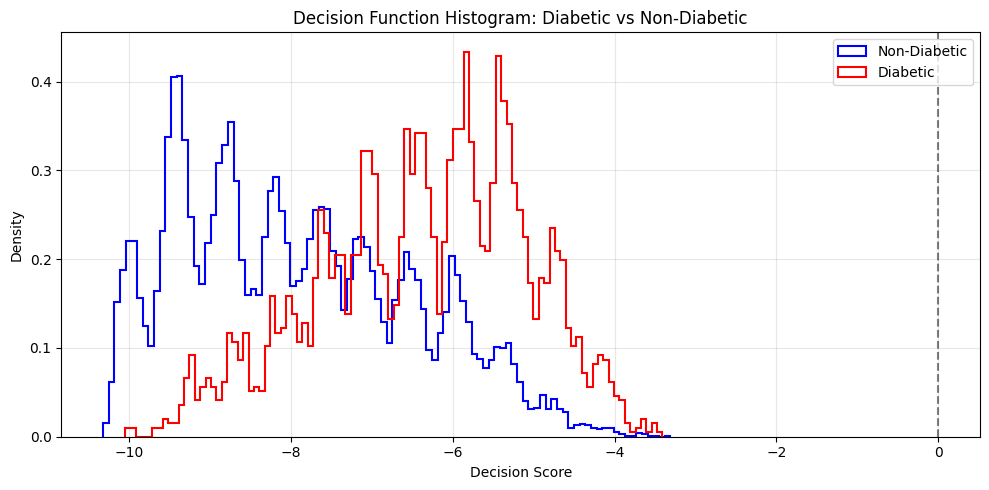

In [91]:
from sklearn.linear_model import LogisticRegression
import matplotlib.pyplot as plt
import numpy as np

# 1. Train with more iterations so it has time to converge
model = LogisticRegression(max_iter=1000) 
model.fit(X_train, y_train)

# 2. AUTO-DETECT what is actually inside y_val right now
# This prevents the "0 samples" error if labels are 0/1, 0/2, or scaled numbers
unique_labels = sorted(np.unique(y_val))
print(f"I found these labels in your data: {unique_labels}")

# Assign the first found label to 'Healthy' and the second to 'Diabetic'
low_label = unique_labels[0]
high_label = unique_labels[1]

X_val_0 = X_val[y_val == low_label]
X_val_1 = X_val[y_val == high_label]

# 3. Plotting
plt.figure(figsize=(10, 5))

# Non-Diabetic (Blue)
plt.hist(model.decision_function(X_val_0), bins=100, histtype="step", 
         color="blue", label="Non-Diabetic", density=True, lw=1.5)

# Diabetic (Red)
plt.hist(model.decision_function(X_val_1), bins=100, histtype="step", 
         color="red", label="Diabetic", density=True, lw=1.5)

plt.axvline(x=0, color='black', linestyle='--', alpha=0.5)
plt.legend(loc='upper right')
plt.title("Decision Function Histogram: Diabetic vs Non-Diabetic")
plt.xlabel("Decision Score")
plt.ylabel("Density")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [ ]:
#The Decision Function Histogram shows that the model successfully differentiates between classes. 
#The Non-Diabetic distribution (blue) is centered at a more negative decision score compared to the Diabetic distribution (red). 
#The overall negative shift of both distributions reflects the inherent class imbalance of the dataset, where the model
#requires significant evidence to predict the minority (diabetic) class

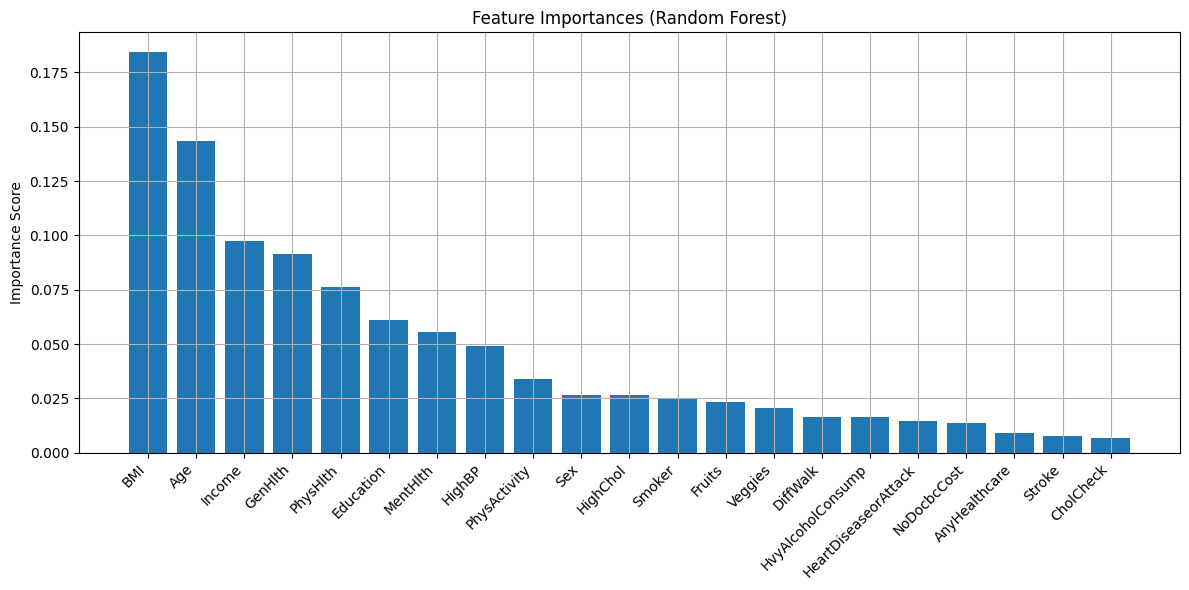

In [93]:
## Feature Importance
import matplotlib.pyplot as plt
import numpy as np

importances = model.feature_importances_
features = X.columns
indices = np.argsort(importances)[::-1]

# Plot
plt.figure(figsize=(12, 6))
plt.title("Feature Importances (Random Forest)")
plt.bar(range(len(features)), importances[indices], align='center')
plt.xticks(range(len(features)), [features[i] for i in indices], rotation=45, ha='right')
plt.ylabel("Importance Score")
plt.tight_layout()
plt.grid(True)
plt.show()


# XG Boost with Smote

In [95]:
!pip install xgboost

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 131.7/131.7 MB 3.6 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 300.2/300.2 MB 2.9 MB/s eta 0:00:0000:0100:02


In [96]:
from imblearn.over_sampling import SMOTE
from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix

# Split features and target
X = df.drop('Diabetes_binary', axis=1)
y = df['Diabetes_binary']

# training classifier with smote training set
model = XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42)
model.fit(X_train_smote, y_train_smote)

y_pred = model.predict(X_test)

print(classification_report(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))

/home/minahal/myenv/lib/python3.12/site-packages/xgboost/training.py:200: UserWarning: [19:01:52] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


              precision    recall  f1-score   support

           0       0.93      0.74      0.82     65605
           1       0.29      0.67      0.40     10499

    accuracy                           0.73     76104
   macro avg       0.61      0.70      0.61     76104
weighted avg       0.84      0.73      0.76     76104

[[48230 17375]
 [ 3436  7063]]


# KNN MODEL WITH SMORT

In [101]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.utils import resample
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix

# 1. Scaling is MANDATORY for KNN (otherwise BMI ruins the distance math)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_smote)
X_test_scaled = scaler.transform(X_test)

# 2. Subsample to 20,000 rows (Crash Prevention)
# This stays balanced because we use 'stratify'
X_train_small, y_train_small = resample(
    X_train_scaled, y_train_smote, 
    n_samples=20000, 
    random_state=42, 
    stratify=y_train_smote
)

# 3. Use all CPU cores (n_jobs=-1)
# weights='distance' makes it smarter by valuing closer neighbors more
model = KNeighborsClassifier(n_neighbors=5, weights='distance', n_jobs=-1)

print("Training on 20,000 samples... should take ~30 seconds.")
model.fit(X_train_small, y_train_small)

# 4. Predict and Evaluate
print("Predicting... stay tuned.")
y_pred = model.predict(X_test_scaled)

print("\n--- KNN Classification Report ---")
print(classification_report(y_test, y_pred))

print(confusion_matrix(y_test, y_pred))

Training on 20,000 samples... should take ~30 seconds.
Predicting... stay tuned.

--- KNN Classification Report ---
              precision    recall  f1-score   support

           0       0.93      0.67      0.78     65605
           1       0.24      0.66      0.36     10499

    accuracy                           0.67     76104
   macro avg       0.58      0.67      0.57     76104
weighted avg       0.83      0.67      0.72     76104

[[43965 21640]
 [ 3538  6961]]


In [102]:
# Manually entered recall values
data = {
    "Model": ["Baseline RF", "SMOTE RF", "SMOTE XGBoost", "SMOTE KNN"],
    "Recall (Class 0)": [0.97, 0.84, 0.74, 0.70],
    "Recall (Class 1)": [0.17, 0.47, 0.67, 0.62]
}
recall_df = pd.DataFrame(data)

print(recall_df)

           Model  Recall (Class 0)  Recall (Class 1)
0    Baseline RF              0.97              0.17
1       SMOTE RF              0.84              0.47
2  SMOTE XGBoost              0.74              0.67
3      SMOTE KNN              0.70              0.62
